<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%206/W6_L1_Object_Detection_Foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=4o-4_VUwRKw) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%206/NPTEL_Jul24_DL4CV_W06_P01.pdf)

In [1]:
# Week 6, Lecture 1: CNN's for obj detection: Pre Deep Learning..
from IPython.display import HTML, display

VIDEO_ID = "4o-4_VUwRKw"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 6, Lecture 1: CNNs for Object Detection (Foundations)

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§6.1 CNNs for Object Detection**.

This notebook is the hands-on companion to the first half of Week 6: everything from the task
taxonomy up to **OverFeat**. R-CNN and its descendants belong to the next lecture.

**Contents**

1. Classification vs Localization vs Detection: the task taxonomy
2. Detection before deep learning: the **Viola-Jones** framework and its three components
3. **Haar-like features**: $f = \sum(\text{black rect}) - \sum(\text{white rect})$
4. **Integral images**: any rectangle sum in $O(1)$, with 6 / 8 / 9 lookups per feature
5. **Weak classifiers**: a threshold plus a parity on a single feature
6. **AdaBoost**: a strong classifier as a weighted vote of weak classifiers
7. **Classifier cascades**: reject the easy negatives first, and why the arithmetic forces this
8. **IoU** and **Non-Maximum Suppression**
9. **HOG** (Dalal and Triggs, 2005) and the linear SVM that reads it
10. **Image pyramids** for multi-scale detection
11. **CNN + sliding window** detection, and why it is wasteful
12. **Bounding box regression** for localization
13. **OverFeat**: fully convolutional networks, where the sliding window becomes one forward pass

**What you will learn**

| # | You build | You verify it against |
|---|-----------|----------------------|
| 1 | The integral image recurrence, written exactly as on the slide | a direct `numpy` sum over every rectangle |
| 2 | Haar features via 6 / 8 / 9 integral-image lookups | the naive pixel-by-pixel sum, and a lookup counter |
| 3 | The 162,336-feature pool of a 24x24 window | the slide's claim of "over 160k features" |
| 4 | Viola-Jones AdaBoost, step for step from the paper | training error that provably falls to zero |
| 5 | A real 3-stage cascade | measured early rejection on a real image scan |
| 6 | IoU and greedy NMS | a slow pixel-mask reference implementation |
| 7 | HOG: gradients, cells, blocks, descriptor | the classic 3780-dimensional Dalal-Triggs number |
| 8 | An image pyramid | it finds a face that the single-scale scan misses |
| 9 | A CNN detector with classification and box regression heads | loose boxes become tight boxes |
| 10 | **OverFeat: FC layers turned into convolutions** | **an exact numerical assert against the sliding window** |

Every primitive is built from the ground up and then proved
equivalent to a slow, obviously-correct reference before it is used. 
**How to run**  Nothing is downloaded: all images are generated procedurally with `numpy`, so
the notebook runs anywhere on a CPU in about two minutes.

## Review

Week 5 ended by looking inside a trained CNN with first-layer filters, feature maps and saliency maps. Everything so far assigns a single label to a whole image. This week asks *where* the objects are, beginning with how detection was done before deep learning.

---
## Setup

* **PyTorch** for the neural networks, `numpy` for the classical vision, `ipywidgets` for the sliders.
* Seeds are fixed everywhere so that every number and figure below is reproducible.
* Everything runs on CPU in reasonable time; a GPU is used automatically if one is present.

**On the sliders:** we use `%matplotlib inline` plus plain `ipywidgets.interact`, which works in
Colab out of the box. Only if a widget misbehaves, run
`from google.colab import output; output.enable_custom_widget_manager()` and re-execute the cell.

In [2]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F
import ipywidgets as widgets
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
from IPython.display import display

SEED = 6
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams.update({'figure.dpi': 110, 'image.cmap': 'gray', 'image.interpolation': 'nearest',
                     'axes.titlesize': 9, 'axes.labelsize': 8, 'font.size': 8})

print('torch', torch.__version__, '| numpy', np.__version__, '| device:', device)

torch 2.8.0 | numpy 2.0.2 | device: cpu


### 0.1 A synthetic world

We need pixels before we can detect anything, and we refuse to download a dataset. So we grow one.

* `make_face` renders a crude **face-like** patch at any size. It deliberately contains the two
  structures that Viola and Jones point at in their paper:
  * a **dark horizontal eye band**, because the eye region is darker than the upper cheeks,
  * a **bright vertical nose bridge** splitting that band.
* `make_scene` composites faces onto a textured background together with **distractors** (bars and
  blobs) that a lazy detector would happily fire on. It returns boxes and masks, so the same
  generator serves classification, localization, detection and segmentation.
* Faces are pasted through an **oval mask**, so there is no square seam for the detector to cheat on.

One generator feeds the whole notebook: Viola-Jones, HOG, the pyramid, the CNN and OverFeat all see
exactly the same detection problem, which is what makes the comparisons at the end meaningful.

In [3]:
def resize(img, out_h, out_w):
    """Bilinear resize (torch does the work, so it is fast and dependency free)."""
    t = torch.from_numpy(np.asarray(img, dtype=np.float32))[None, None]
    return F.interpolate(t, size=(int(out_h), int(out_w)), mode='bilinear',
                         align_corners=False)[0, 0].numpy().astype(np.float64)


def smooth_noise(h, w, rng, k=16):
    """Low frequency texture: a small random array blown up to (h, w)."""
    return resize(rng.random((max(2, h // k), max(2, w // k))), h, w)


def make_face(size, rng):
    """A synthetic face-like patch in [0, 1] plus its oval (head) mask.

    Geometry is defined in normalised coordinates, so the same face renders at any size.
    """
    g = (np.arange(size) + 0.5) / size
    yy, xx = np.meshgrid(g, g, indexing='ij')
    img = np.full((size, size), 0.62 + rng.uniform(-0.05, 0.05))
    head = (((xx - 0.5) / 0.44) ** 2 + ((yy - 0.52) / 0.47) ** 2) <= 1.0

    img += 0.10 * np.clip(1.0 - yy / 0.30, 0, 1)                      # brighter forehead
    eyes = head & (yy > 0.28) & (yy < 0.48)                           # dark eye band
    img[eyes] -= rng.uniform(0.28, 0.38)
    bridge = eyes & (xx > 0.38) & (xx < 0.62)                         # bright nose bridge
    img[bridge] += rng.uniform(0.34, 0.44)
    mouth = head & (yy > 0.68) & (yy < 0.82) & (xx > 0.28) & (xx < 0.72)
    img[mouth] -= rng.uniform(0.14, 0.24)
    img += rng.normal(0, 0.025, img.shape)
    return np.clip(img, 0, 1), head


def add_distractors(img, rng, n):
    """Bars and blobs: structured clutter with face-like contrast but the wrong geometry."""
    H, W = img.shape
    yy, xx = np.mgrid[0:H, 0:W]
    for _ in range(n):
        kind = rng.integers(0, 3)
        sign = rng.choice([-1.0, 1.0])
        amp = rng.uniform(0.18, 0.34)
        if kind == 0:                                                  # horizontal bar
            y0, x0 = rng.integers(0, H - 8), rng.integers(0, W - 20)
            img[y0:y0 + rng.integers(3, 8), x0:x0 + rng.integers(12, 26)] += sign * amp
        elif kind == 1:                                                # vertical bar
            y0, x0 = rng.integers(0, H - 20), rng.integers(0, W - 8)
            img[y0:y0 + rng.integers(12, 26), x0:x0 + rng.integers(3, 8)] += sign * amp
        else:                                                          # blob
            cy, cx = rng.integers(6, H - 6), rng.integers(6, W - 6)
            r = rng.integers(4, 9)
            img[((yy - cy) ** 2 + (xx - cx) ** 2) <= r ** 2] += sign * amp
    return img


def make_scene(rng, face_specs=(), H=120, W=160, n_distract=7):
    """Composite a scene. face_specs is a list of (cx, cy, size). Returns img, boxes, masks."""
    img = 0.34 + 0.32 * smooth_noise(H, W, rng, k=16)
    img = add_distractors(img, rng, n_distract)
    boxes, masks = [], []
    for (cx, cy, s) in face_specs:
        face, head = make_face(int(s), rng)
        x0, y0 = int(cx - s // 2), int(cy - s // 2)
        region = img[y0:y0 + s, x0:x0 + s]
        img[y0:y0 + s, x0:x0 + s] = np.where(head, face, region)       # paste through the oval
        m = np.zeros((H, W), bool)
        m[y0:y0 + s, x0:x0 + s] = head
        boxes.append([x0, y0, x0 + s, y0 + s])
        masks.append(m)
    img = np.clip(img + rng.normal(0, 0.02, img.shape), 0, 1)
    return img, np.array(boxes, float).reshape(-1, 4), masks


def sample_face_specs(rng, n, H=120, W=160, size_range=(14, 19), pad=3, min_gap=30):
    """Rejection-sample n non-overlapping face placements."""
    out = []
    for _ in range(400):
        if len(out) == n:
            break
        s = int(rng.integers(*size_range))
        cx = int(rng.integers(s // 2 + pad, W - s // 2 - pad))
        cy = int(rng.integers(s // 2 + pad, H - s // 2 - pad))
        if all(abs(cx - ox) + abs(cy - oy) > min_gap for ox, oy, _ in out):
            out.append((cx, cy, s))
    return out


print('generators ready')

generators ready


### 0.2 The image we will detect on

This is the canvas that Viola-Jones, HOG, the pyramid, the CNN and OverFeat will all be pointed at.
It holds **four faces**: three of size 16 pixels and **one of size 48**. Remember that big one. Our
detector will only ever look through a 24x24 window, so the best it could possibly do on a 48px face
is to box a quarter of it ($IoU = 24^2/48^2 = 0.25$). Only the **image pyramid** in section 10 will
actually find it.

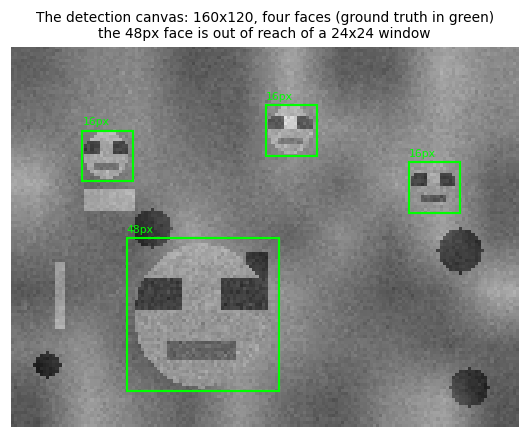

canvas (120, 160) | ground truth boxes:
 [[ 22  26  38  42]
 [ 80  18  96  34]
 [125  36 141  52]
 [ 36  60  84 108]]


In [4]:
DEMO_FACES = [(30, 34, 16), (88, 26, 16), (133, 44, 16), (60, 84, 48)]   # (cx, cy, size)
scene_rng = np.random.default_rng(11)
CANVAS, CANVAS_BOXES, CANVAS_MASKS = make_scene(scene_rng, DEMO_FACES)

fig, ax = plt.subplots(figsize=(5.2, 4.0))
ax.imshow(CANVAS, vmin=0, vmax=1)
for (x1, y1, x2, y2), (cx, cy, s) in zip(CANVAS_BOXES, DEMO_FACES):
    ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec='lime', lw=1.4))
    ax.text(x1, y1 - 2, '%dpx' % s, color='lime', fontsize=7)
ax.set_title('The detection canvas: %dx%d, four faces (ground truth in green)'
             % CANVAS.shape[::-1] + '\nthe 48px face is out of reach of a 24x24 window')
ax.axis('off')
plt.tight_layout(); plt.show()
print('canvas', CANVAS.shape, '| ground truth boxes:\n', CANVAS_BOXES.astype(int))

---
## 1. Classification vs Localization vs Detection

The taxonomy that opens the lecture, in one figure. The tasks differ along two axes: **how many
objects**, and **how precisely** we must say where they are.

| Task | Output | How many objects |
|------|--------|------------------|
| **Classification** | one class label | single |
| **Classification + Localization** | one class label **and one box** | single |
| **Object Detection** | a class label and a box **per object** | multiple, unknown count |
| **Instance Segmentation** | a class label and a **pixel mask** per object | multiple, unknown count |

* The jump from classification to localization adds a **regression** output next to the softmax.
* The jump from localization to detection is the hard one: **the number of outputs is not known in
  advance**. A fixed-size network head cannot emit a variable-length list of boxes.
* Nearly everything in this lecture is a strategy for dodging that one problem: **turn detection
  into many classification problems**, one per candidate window, then clean up the mess with NMS.
* Instance segmentation is Lecture 4 of this week; we show it only to complete the picture.

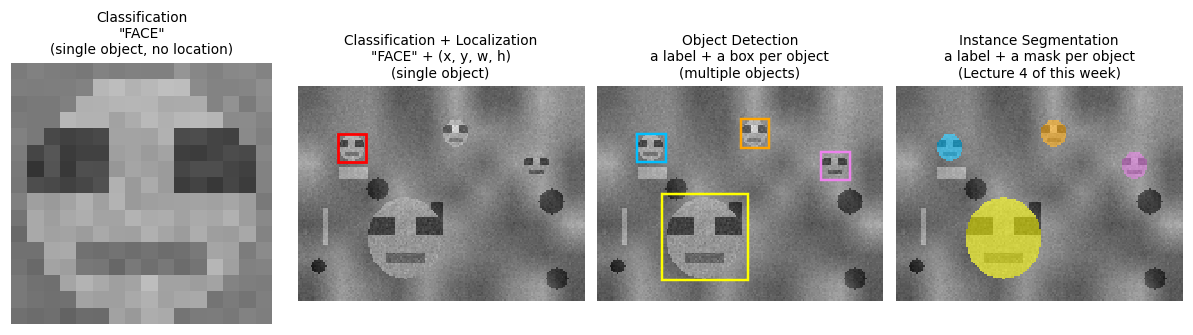

Key difficulty: panels 3 and 4 need a VARIABLE number of outputs.
A fixed-size network head cannot do that, hence sliding windows, then proposals, then NMS.


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(11, 2.9))
colors = ['deepskyblue', 'orange', 'violet', 'yellow']

# 1: classification, a tight crop, one label, no location
x1, y1, x2, y2 = CANVAS_BOXES[0].astype(int)
axes[0].imshow(CANVAS[y1:y2, x1:x2], vmin=0, vmax=1)
axes[0].set_title('Classification\n"FACE"\n(single object, no location)')

# 2: classification + localization, one object, one box
axes[1].imshow(CANVAS, vmin=0, vmax=1)
axes[1].add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec='red', lw=1.8))
axes[1].set_title('Classification + Localization\n"FACE" + (x, y, w, h)\n(single object)')

# 3: detection, one box per object
axes[2].imshow(CANVAS, vmin=0, vmax=1)
for b, c in zip(CANVAS_BOXES, colors):
    axes[2].add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1],
                                         fill=False, ec=c, lw=1.6))
axes[2].set_title('Object Detection\na label + a box per object\n(multiple objects)')

# 4: instance segmentation, one mask per object
overlay = np.stack([CANVAS] * 3, -1)
for m, c in zip(CANVAS_MASKS, colors):
    rgb = np.array(plt.matplotlib.colors.to_rgb(c))
    overlay[m] = 0.45 * overlay[m] + 0.55 * rgb
axes[3].imshow(overlay)
axes[3].set_title('Instance Segmentation\na label + a mask per object\n(Lecture 4 of this week)')

for a in axes:
    a.axis('off')
plt.tight_layout(); plt.show()

print('Key difficulty: panels 3 and 4 need a VARIABLE number of outputs.')
print('A fixed-size network head cannot do that, hence sliding windows, then proposals, then NMS.')

---
## 2. Detection in the pre-deep-learning era: Viola-Jones

> Viola and Jones, *Rapid Object Detection using a Boosted Cascade of Simple Features*, CVPR 2001.

* The first framework to do face detection in **real time** (15 fps in 2001, on a 700 MHz CPU).
* Used predominantly for **frontal upright faces**, which is exactly what our synthetic canvas has.
* It is a **sliding window** detector: it asks "face or not?" at every position and every scale.
  The entire design is about making that question absurdly cheap to ask.

It rests on three components, and we build all three:

| # | Component | The problem it solves | Section |
|---|-----------|----------------------|---------|
| 1 | **Haar-like features + Integral Images** | a feature must cost a handful of array lookups | 3, 4 |
| 2 | **AdaBoost** | 160k candidate features exist, pick the few that matter | 5, 6 |
| 3 | **Classifier cascades** | almost every window is background, do not waste time on it | 7 |

Read those three as answers to three questions: *what is a cheap feature*, *which features*, and
*how few of them do we have to look at*.

---
## 3. Haar-like features

A Haar-like feature is a **difference of rectangle sums**, inspired by Haar wavelets. Following the
slide, with black and white denoting the two rectangle groups:

$$f = \sum(\text{pixels inside black rectangle}) - \sum(\text{pixels inside white rectangle})$$

The five standard types, each defined by a **type**, a **position** $(x, y)$ and a **size** $(w, h)$
inside the detection window:

* `2h`, `2v` (**edge features**): two rectangles side by side or stacked. Respond to edges.
* `3h`, `3v` (**line features**): three rectangles, black in the centre. Respond to bars and lines.
  Viola and Jones define these as *the sum in a centre rectangle minus the sum in two outside rectangles*.
* `4` (**four-rectangle feature**): a 2x2 checkerboard. Responds to diagonal structure.

Why these are the right primitive:

* They are **crude**: a Haar feature is a box filter difference, far weaker than a Gabor or a SIFT
  descriptor. Viola and Jones accept that weakness deliberately.
* In exchange they are **almost free to compute**, once we have the integral image of section 4.
  Cheap and weak, evaluated by the thousands, beats expensive and strong.
* Features are **scaled through height and width** rather than by resampling the image, so a
  detector can change scale without ever rebuilding an image pyramid.

We represent a feature as a list of `(x, y, w, h, sign)` rectangles with `sign = +1` for black and
`sign = -1` for white, so the code below is literally the equation above.

In [6]:
def haar_rects(ftype, x, y, w, h):
    """Rectangles of a Haar feature whose bounding box is (x, y, w, h).

    Returns a list of (rx, ry, rw, rh, sign); sign = +1 is black, sign = -1 is white,
    so that  f = sum(sign * rect_sum)  is exactly  sum(black) - sum(white).
    """
    if ftype == '2h':                              # black | white   (side by side)
        u = w // 2
        return [(x, y, u, h, +1), (x + u, y, u, h, -1)]
    if ftype == '2v':                              # black over white (stacked)
        v = h // 2
        return [(x, y, w, v, +1), (x, y + v, w, v, -1)]
    if ftype == '3h':                              # white | black | white
        u = w // 3
        return [(x, y, u, h, -1), (x + u, y, u, h, +1), (x + 2 * u, y, u, h, -1)]
    if ftype == '3v':                              # white over black over white
        v = h // 3
        return [(x, y, w, v, -1), (x, y + v, w, v, +1), (x, y + 2 * v, w, v, -1)]
    if ftype == '4':                               # 2x2 checkerboard
        u, v = w // 2, h // 2
        return [(x, y, u, v, +1), (x + u, y, u, v, -1),
                (x, y + v, u, v, -1), (x + u, y + v, u, v, +1)]
    raise ValueError('unknown feature type %r' % ftype)


def rect_sum_naive(img, x, y, w, h):
    """The slow, obviously correct reference: actually add up the pixels."""
    return float(img[y:y + h, x:x + w].sum())


def haar_value_naive(img, ftype, x, y, w, h):
    """f = sum(black) - sum(white), computed the slow way."""
    return sum(s * rect_sum_naive(img, rx, ry, rw, rh)
               for (rx, ry, rw, rh, s) in haar_rects(ftype, x, y, w, h))


def haar_mask(ftype, x, y, w, h, win=24):
    """A picture of the feature: +1 black, -1 white, 0 untouched. For plotting only."""
    m = np.zeros((win, win))
    for (rx, ry, rw, rh, s) in haar_rects(ftype, x, y, w, h):
        m[ry:ry + rh, rx:rx + rw] = s
    return m


# Sanity check on a hand made patch: a bright top half over a dark bottom half.
test = np.zeros((24, 24)); test[:12, :] = 1.0
print('2v feature on a bright-over-dark patch (black rect on the bright half):')
print('   f = sum(black) - sum(white) = %.0f - %.0f = %+.0f'
      % (rect_sum_naive(test, 0, 0, 24, 12), rect_sum_naive(test, 0, 12, 24, 12),
         haar_value_naive(test, '2v', 0, 0, 24, 24)))
print('   same feature on a constant patch: f = %+.0f  (edge features cancel on flat regions)'
      % haar_value_naive(np.ones((24, 24)), '2v', 0, 0, 24, 24))

2v feature on a bright-over-dark patch (black rect on the bright half):
   f = sum(black) - sum(white) = 288 - 0 = +288
   same feature on a constant patch: f = +0  (edge features cancel on flat regions)


### 3.1 Haar features: the intuition

This is the figure from the slides, rebuilt on our synthetic face. The two features Viola and Jones
single out in the paper:

* **Feature 1** (`2v`, an edge feature): the **eye region is darker than the upper cheeks**. Place
  the black rectangle on the eyes and the white rectangle just below it, and $f$ swings strongly
  negative on a face and sits near zero on flat background.
* **Feature 2** (`3h`, a line feature): the **eyes are darker than the bridge of the nose**. Place
  the black centre rectangle on the bridge and the white rectangles on the eyes.

The point of the figure is the **contrast between the two rows**: the identical feature that
screams on a face is silent on background. That gap is all a weak classifier needs.

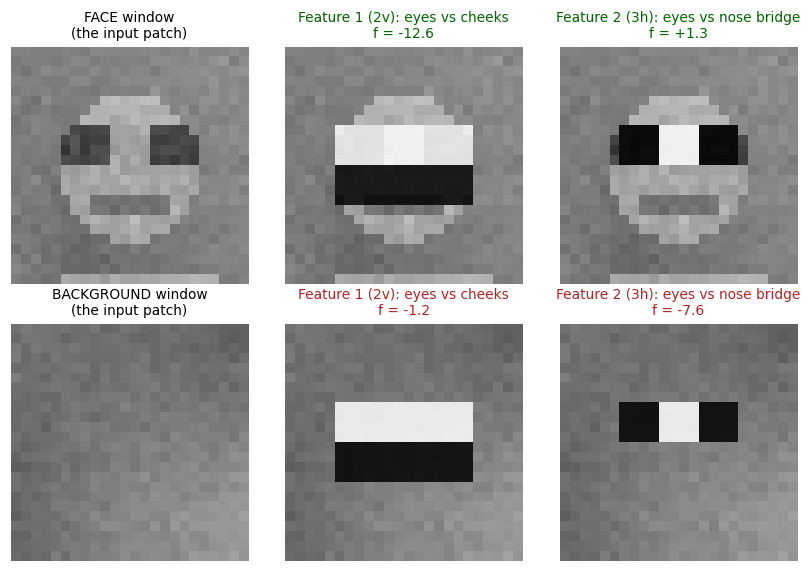

eyes vs cheeks : f(face) =  -12.62   f(background) =   -1.19   separation = 11.43
eyes vs bridge : f(face) =   +1.32   f(background) =   -7.57   separation =  8.89


In [7]:
face_patch = CANVAS[22:46, 18:42].copy()          # the 24x24 window centred on the first face
bg_patch = CANVAS[92:116, 108:132].copy()         # a 24x24 window of background clutter

EYE_FEAT = ('2v', 5, 8, 14, 8)                    # black on the eyes, white on the cheeks below
NOSE_FEAT = ('3h', 6, 8, 12, 4)                   # white | black | white across eyes and bridge

fig, axes = plt.subplots(2, 3, figsize=(7.6, 5.2))
for row, (patch, name) in enumerate([(face_patch, 'FACE window'), (bg_patch, 'BACKGROUND window')]):
    axes[row, 0].imshow(patch, vmin=0, vmax=1)
    axes[row, 0].set_title('%s\n(the input patch)' % name)
    for col, (feat, label) in enumerate([(EYE_FEAT, 'Feature 1 (2v): eyes vs cheeks'),
                                         (NOSE_FEAT, 'Feature 2 (3h): eyes vs nose bridge')]):
        ax = axes[row, col + 1]
        m = haar_mask(*feat)
        ax.imshow(patch, vmin=0, vmax=1)
        ax.imshow(np.ma.masked_where(m == 0, m), cmap='gray', vmin=-1, vmax=1, alpha=0.85)
        v = haar_value_naive(patch, *feat)
        ax.set_title('%s\nf = %+.1f' % (label, v), color=('darkgreen' if row == 0 else 'firebrick'))
for a in axes.ravel():
    a.axis('off')
plt.tight_layout(); plt.show()

for feat, label in [(EYE_FEAT, 'eyes vs cheeks '), (NOSE_FEAT, 'eyes vs bridge ')]:
    vf, vb = haar_value_naive(face_patch, *feat), haar_value_naive(bg_patch, *feat)
    print('%s: f(face) = %+7.2f   f(background) = %+7.2f   separation = %5.2f'
          % (label, vf, vb, abs(vf - vb)))

### 3.2 Interactive: explore the feature pool

Move the sliders and watch $f$ change. Things worth discovering:

* Slide the `2v` feature **down from the eyes to the cheeks**: the response collapses. A Haar
  feature is **position sensitive**, which is exactly why the pool needs a feature at every position.
* Grow `w` and `h`: the response grows roughly with the **area**, not with the structure. This is
  why every feature carries its **own learned threshold**: responses are not comparable across sizes.
* Find a feature that separates the face from the background well, and one that does not. The vast
  majority of the 160k features are useless. Section 6 is about letting AdaBoost find the few good ones.

In [8]:
def haar_explorer(ftype='2v', x=3, y=6, w=18, h=8):
    if x + w > 24 or y + h > 24:
        print('feature falls outside the 24x24 window, shrink it'); return
    m = haar_mask(ftype, x, y, w, h)
    fig, axes = plt.subplots(1, 3, figsize=(8.4, 2.9))
    axes[0].imshow(np.where(m == 0, 0.5, (m + 1) / 2), vmin=0, vmax=1)
    axes[0].set_title('feature %r at (%d,%d) size %dx%d\nblack = +1, white = -1' % (ftype, x, y, w, h))
    for ax, patch, name in [(axes[1], face_patch, 'FACE'), (axes[2], bg_patch, 'BACKGROUND')]:
        ax.imshow(patch, vmin=0, vmax=1)
        ax.imshow(np.ma.masked_where(m == 0, m), cmap='gray', vmin=-1, vmax=1, alpha=0.85)
        ax.set_title('%s: f = %+.1f' % (name, haar_value_naive(patch, ftype, x, y, w, h)))
    for a in axes:
        a.axis('off')
    plt.tight_layout(); plt.show()
    d = abs(haar_value_naive(face_patch, ftype, x, y, w, h) -
            haar_value_naive(bg_patch, ftype, x, y, w, h))
    print('|f(face) - f(background)| = %.2f    <- a weak classifier can only use this gap' % d)


interact(haar_explorer,
         ftype=Dropdown(options=['2h', '2v', '3h', '3v', '4'], value='2v', description='type'),
         x=IntSlider(value=3, min=0, max=23, step=1, description='x'), y=IntSlider(value=6, min=0, max=23, step=1, description='y'),
         w=IntSlider(value=18, min=2, max=24, step=1, description='w'), h=IntSlider(value=8, min=2, max=24, step=1, description='h'));

interactive(children=(Dropdown(description='type', index=1, options=('2h', '2v', '3h', '3v', '4'), value='2v')…

---
## 4. The integral image

Haar features are sums over rectangles, and a 24x24 window contains 160k of them. Adding pixels one
by one is hopeless. The integral image makes **every rectangle sum cost the same**, no matter how
big the rectangle is.

**Definition.** For an image $i$, the integral image $ii$ is

$$ii(x, y) = \sum_{x' \le x,\; y' \le y} i(x', y')$$

that is, $ii(x,y)$ is the sum of everything above and to the left of $(x, y)$, inclusive.
Throughout, following the slide, **$x$ indexes columns and $y$ indexes rows**.

**The recurrence.** Written naively that definition is $O(N^2)$ per pixel. It is computed instead in
**one pass** over the image with a pair of recurrences:

$$s(x, y) = s(x, y-1) + i(x, y)$$
$$ii(x, y) = ii(x-1, y) + s(x, y)$$

with $s(x, -1) = 0$ and $ii(-1, y) = 0$, where $s(x,y)$ is the **cumulative row sum**.

* $s$ accumulates **down a column**, then $ii$ accumulates that **across the rows**.
* Each pixel costs two additions, so the whole table is built in $O(HW)$: cheaper than a single
  convolution, and done exactly once per image.

In [9]:
def integral_image_scratch(img):
    """The Viola-Jones recurrence, written exactly as on the slide.

        s(x, y)  = s(x, y-1) + i(x, y)          cumulative row sum
        ii(x, y) = ii(x-1, y) + s(x, y)
        s(x, -1) = 0,  ii(-1, y) = 0

    x indexes columns and y indexes rows, so img[y, x] is i(x, y).
    """
    H, W = img.shape
    s = np.zeros((H, W))
    ii = np.zeros((H, W))
    for y in range(H):
        for x in range(W):
            s[y, x] = (s[y - 1, x] if y > 0 else 0.0) + img[y, x]      # s(x, y-1) + i(x, y)
            ii[y, x] = (ii[y, x - 1] if x > 0 else 0.0) + s[y, x]      # ii(x-1, y) + s(x, y)
    return ii


# Verification 1: against the definition itself, summed by brute force.
rng_v = np.random.default_rng(0)
small = rng_v.random((8, 10))
ii_scratch = integral_image_scratch(small)
ii_bruteforce = np.array([[small[:y + 1, :x + 1].sum() for x in range(10)] for y in range(8)])
print('recurrence == definition   :', np.allclose(ii_scratch, ii_bruteforce))

# Verification 2: against the vectorised numpy equivalent (this is what we use from now on).
print('recurrence == cumsum.cumsum:', np.allclose(ii_scratch, small.cumsum(0).cumsum(1)))
print('\nThe two recurrences ARE a 2-D cumulative sum. numpy does it in C, so we let it.')

recurrence == definition   : True
recurrence == cumsum.cumsum: True

The two recurrences ARE a 2-D cumulative sum. numpy does it in C, so we let it.


### 4.1 Any rectangle in $O(1)$: the slide's "(Why?)"

With the four corners of a rectangle numbered **1** (upper left), **2** (upper right), **3** (lower
left) and **4** (lower right), and with **A, B, C, D** naming the four regions of the figure, the
sum inside rectangle **D** is

$$\text{sum}(D) = ii(4) + ii(1) - \big(ii(2) + ii(3)\big)$$

**Why.** Just expand each lookup into the regions it covers:

* $ii(1) = A$
* $ii(2) = A + B$
* $ii(3) = A + C$
* $ii(4) = A + B + C + D$

so $ii(4) + ii(1) - ii(2) - ii(3) = (A{+}B{+}C{+}D) + A - (A{+}B) - (A{+}C) = D.$

Subtracting $ii(2)$ and $ii(3)$ removes $B$ and $C$ but removes $A$ **twice**, so adding $ii(1)$ back
puts it right. That is the whole trick: **four lookups, three additions, no dependence on area**.

In code we keep a **zero row and column of padding**, which makes the $x-1 < 0$ and $y-1 < 0$ cases
disappear. Written formally, as on the slide, for a rectangle with upper-left $(x_1, y_1)$ and
bottom-right $(x_2, y_2)$:

$$\text{Sum} = ii(x_2, y_2) + ii(x_1 - 1, y_1 - 1) - \big(ii(x_1 - 1, y_2) + ii(x_2, y_1 - 1)\big)$$

In [10]:
def integral_image(img):
    """Padded integral image: II[y, x] = sum of img[:y, :x].

    The zero row and column remove the (x-1 < 0) and (y-1 < 0) special cases, so rect_sum
    below needs no branches. II has shape (H+1, W+1).
    """
    return np.pad(np.asarray(img, float).cumsum(0).cumsum(1), ((1, 0), (1, 0)))


def rect_sum(II, x, y, w, h):
    """Sum of img[y:y+h, x:x+w] in O(1) with 4 lookups. Corners numbered as on the slide."""
    ii1 = II[y,     x]          # corner 1, upper left    -> covers A
    ii2 = II[y,     x + w]      # corner 2, upper right   -> covers A + B
    ii3 = II[y + h, x]          # corner 3, lower left    -> covers A + C
    ii4 = II[y + h, x + w]      # corner 4, lower right   -> covers A + B + C + D
    return ii4 + ii1 - ii2 - ii3


def haar_value(II, ftype, x, y, w, h):
    """f = sum(black) - sum(white), now in a constant number of lookups."""
    return sum(s * rect_sum(II, rx, ry, rw, rh)
               for (rx, ry, rw, rh, s) in haar_rects(ftype, x, y, w, h))


# Exhaustive verification: EVERY rectangle sum must equal the naive pixel sum.
II_patch = integral_image(face_patch)
worst, checked = 0.0, 0
for w in range(1, 25):
    for h in range(1, 25):
        for x in range(0, 25 - w):
            for y in range(0, 25 - h):
                fast = rect_sum(II_patch, x, y, w, h)
                slow = rect_sum_naive(face_patch, x, y, w, h)
                worst = max(worst, abs(fast - slow)); checked += 1
print('checked ALL %d rectangles of the 24x24 window' % checked)
print('worst |integral image - naive sum| = %.3e   (exact up to float rounding)' % worst)
assert worst < 1e-9

checked ALL 90000 rectangles of the 24x24 window
worst |integral image - naive sum| = 1.457e-13   (exact up to float rounding)


### 4.2 The slide's worked example, reproduced

The lecture works a 6x6 example by hand and gets **199**. Let us check the slide.

In [11]:
slide_img = np.array([[38, 66, 17, 57, 73,  2],
                      [89, 97, 98, 30,  2, 89],
                      [15, 37, 75, 81, 23, 50],
                      [96, 70, 63, 84, 41, 29],
                      [93, 84, 89, 46, 28, 26],
                      [74, 74, 51, 96, 64, 39]], float)
slide_ii = integral_image_scratch(slide_img)        # unpadded, exactly as printed on the slide

# The slide sums the rectangle with upper-left (x1,y1)=(3,3) and bottom-right (x2,y2)=(4,4).
x1, y1, x2, y2 = 3, 3, 4, 4
formula = (slide_ii[y2, x2] + slide_ii[y1 - 1, x1 - 1]
           - (slide_ii[y2, x1 - 1] + slide_ii[y1 - 1, x2]))
direct = slide_img[y1:y2 + 1, x1:x2 + 1].sum()

print('integral image (matches the slide exactly):')
print(slide_ii.astype(int))
print('\nSum = ii(x2,y2) + ii(x1-1,y1-1) - ( ii(x1-1,y2) + ii(x2,y1-1) )')
print('    = %.0f + %.0f - ( %.0f + %.0f ) = %.0f'
      % (slide_ii[y2, x2], slide_ii[y1 - 1, x1 - 1], slide_ii[y2, x1 - 1],
         slide_ii[y1 - 1, x2], formula))
print('direct sum of the 4 pixels %s = %.0f' % (slide_img[y1:y2+1, x1:x2+1].ravel().astype(int), direct))
print('\nthe slide says 1492 + 532 - 1027 - 798 = 199 ->', formula == direct == 199)

integral image (matches the slide exactly):
[[  38  104  121  178  251  253]
 [ 127  290  405  492  567  658]
 [ 142  342  532  700  798  939]
 [ 238  508  761 1013 1152 1322]
 [ 331  685 1027 1325 1492 1688]
 [ 405  833 1226 1620 1851 2086]]

Sum = ii(x2,y2) + ii(x1-1,y1-1) - ( ii(x1-1,y2) + ii(x2,y1-1) )
    = 1492 + 532 - ( 1027 + 798 ) = 199
direct sum of the 4 pixels [84 41 46 28] = 199

the slide says 1492 + 532 - 1027 - 798 = 199 -> True


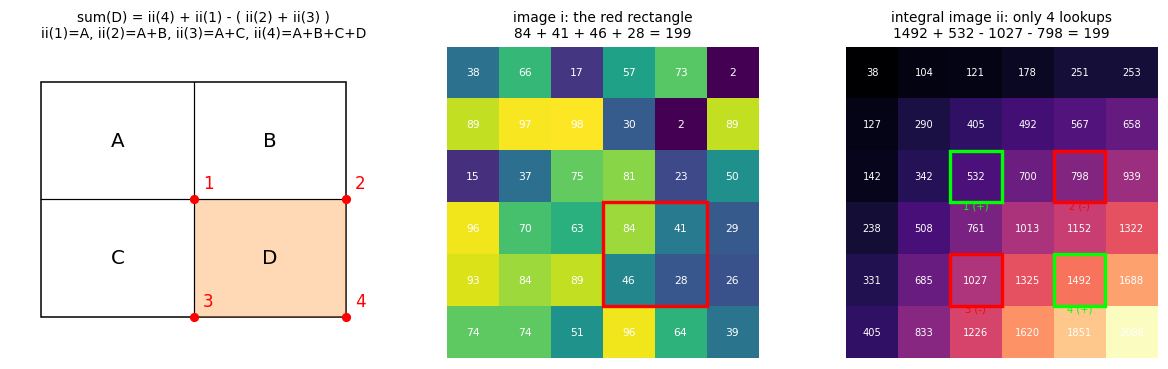

In [12]:
fig = plt.figure(figsize=(11, 3.4))

# Panel 1: the schematic from the slide (regions A, B, C, D and corners 1, 2, 3, 4).
ax = fig.add_subplot(1, 3, 1)
ax.add_patch(mpatches.Rectangle((0, 0), 6, 4, fc='none', ec='k'))
ax.plot([0, 6], [2, 2], 'k-', lw=0.8); ax.plot([3, 3], [0, 4], 'k-', lw=0.8)
ax.add_patch(mpatches.Rectangle((3, 0), 3, 2, fc='tab:orange', alpha=0.30))
for (tx, ty, s) in [(1.5, 3, 'A'), (4.5, 3, 'B'), (1.5, 1, 'C'), (4.5, 1, 'D')]:
    ax.text(tx, ty, s, ha='center', va='center', fontsize=13)
for (tx, ty, s) in [(3, 2, '1'), (6, 2, '2'), (3, 0, '3'), (6, 0, '4')]:
    ax.plot(tx, ty, 'ro', ms=5)
    ax.text(tx + 0.18, ty + 0.18, s, color='red', fontsize=11)
ax.set_xlim(-0.6, 7); ax.set_ylim(-0.7, 4.6); ax.axis('off')
ax.set_title('sum(D) = ii(4) + ii(1) - ( ii(2) + ii(3) )\nii(1)=A, ii(2)=A+B, ii(3)=A+C, ii(4)=A+B+C+D')

# Panel 2: the 6x6 image with the target rectangle.
ax = fig.add_subplot(1, 3, 2)
ax.imshow(slide_img, cmap='viridis')
for (yy, xx), v in np.ndenumerate(slide_img):
    ax.text(xx, yy, '%d' % v, ha='center', va='center', fontsize=7, color='w')
ax.add_patch(mpatches.Rectangle((x1 - .5, y1 - .5), x2 - x1 + 1, y2 - y1 + 1,
                                fill=False, ec='red', lw=2.2))
ax.set_title('image i: the red rectangle\n84 + 41 + 46 + 28 = 199'); ax.axis('off')

# Panel 3: the integral image with the four corner lookups annotated.
ax = fig.add_subplot(1, 3, 3)
ax.imshow(slide_ii, cmap='magma')
for (yy, xx), v in np.ndenumerate(slide_ii):
    ax.text(xx, yy, '%d' % v, ha='center', va='center', fontsize=6.5, color='w')
for (cx, cy, lab, col) in [(x1 - 1, y1 - 1, '1 (+)', 'lime'), (x2, y1 - 1, '2 (-)', 'red'),
                           (x1 - 1, y2, '3 (-)', 'red'), (x2, y2, '4 (+)', 'lime')]:
    ax.add_patch(mpatches.Rectangle((cx - .5, cy - .5), 1, 1, fill=False, ec=col, lw=2.2))
    ax.text(cx, cy + 0.62, lab, ha='center', fontsize=6.5, color=col)
ax.set_title('integral image ii: only 4 lookups\n1492 + 532 - 1027 - 798 = 199'); ax.axis('off')

plt.tight_layout(); plt.show()

### 4.3 How many lookups per feature? (the slide's homework)

The slide states that a 2-rectangle feature needs **6** lookups and asks how many the 3-rectangle
and 4-rectangle features need. We do not have to guess: **count the distinct corners**.

* Four lookups per rectangle would mean 8, 12 and 16 for the 2, 3 and 4-rectangle features.
* But the rectangles of a Haar feature are **adjacent**, so they **share corners**. Every shared
  corner is a lookup we do not repeat.
* For a feature made of a $k \times l$ grid of rectangles, the distinct corners form a
  $(k{+}1) \times (l{+}1)$ lattice, so the count is $(k{+}1)(l{+}1)$.

That predicts $2 \times 3 = 6$, $2 \times 4 = 8$ and $3 \times 3 = 9$. Let us count them in code.

In [13]:
def corner_lookups(ftype, x, y, w, h):
    """The distinct integral image entries a feature actually touches."""
    corners = set()
    for (rx, ry, rw, rh, s) in haar_rects(ftype, x, y, w, h):
        corners |= {(rx, ry), (rx + rw, ry), (rx, ry + rh), (rx + rw, ry + rh)}
    return sorted(corners)


print('%-6s %-22s %8s %10s %8s' % ('type', 'description', 'rects', 'naive 4/rect', 'distinct'))
print('-' * 60)
for ftype, desc, grid in [('2h', '2 rects, side by side', '1x2'), ('2v', '2 rects, stacked', '2x1'),
                          ('3h', '3 rects, side by side', '1x3'), ('3v', '3 rects, stacked', '3x1'),
                          ('4',  '4 rects, checkerboard', '2x2')]:
    rects = haar_rects(ftype, 0, 0, 12, 12)
    print('%-6s %-22s %8d %10d %8d' % (ftype, desc, len(rects), 4 * len(rects),
                                       len(corner_lookups(ftype, 0, 0, 12, 12))))
print('\nHOMEWORK ANSWER: 2-rectangle -> 6 lookups, 3-rectangle -> 8, 4-rectangle -> 9.')
print('Rule: a k x l grid of rectangles has (k+1)(l+1) distinct corners.')
print('Either way it is a CONSTANT, independent of how large the feature is.')

type   description               rects naive 4/rect distinct
------------------------------------------------------------
2h     2 rects, side by side         2          8        6
2v     2 rects, stacked              2          8        6
3h     3 rects, side by side         3         12        8
3v     3 rects, stacked              3         12        8
4      4 rects, checkerboard         4         16        9

HOMEWORK ANSWER: 2-rectangle -> 6 lookups, 3-rectangle -> 8, 4-rectangle -> 9.
Rule: a k x l grid of rectangles has (k+1)(l+1) distinct corners.
Either way it is a CONSTANT, independent of how large the feature is.


### 4.4 $O(1)$ is not a figure of speech

The naive rectangle sum costs $O(\text{area})$; the integral image costs $O(1)$. Below we time both
against rectangle size on a 512x512 image. The naive curve climbs with a slope of 1 on the log-log
plot (cost proportional to area), while the integral image curve is **flat**: a 256x256 rectangle
costs exactly what a 4x4 rectangle costs, because it is the same four lookups.

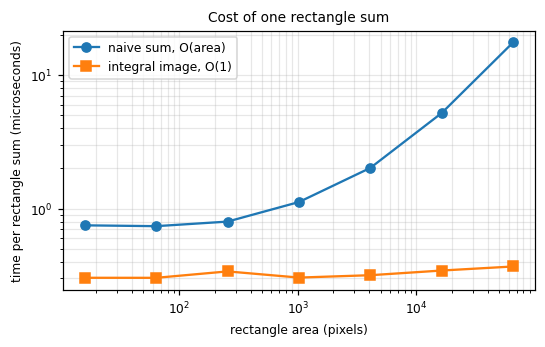

rect             naive (us)  integral (us)    speedup
4x4                    0.75           0.30       2.5x
8x8                    0.74           0.30       2.4x
16x16                  0.80           0.34       2.4x
32x32                  1.12           0.30       3.7x
64x64                  2.01           0.32       6.3x
128x128                5.19           0.34      15.1x
256x256               17.50           0.37      47.5x

The integral image row is flat: that is the whole point.


In [14]:
big = np.random.default_rng(1).random((512, 512))
II_big = integral_image(big)
sizes = [4, 8, 16, 32, 64, 128, 256]
t_naive, t_fast, reps = [], [], 200

for s in sizes:
    t0 = time.perf_counter()
    for _ in range(reps):
        rect_sum_naive(big, 10, 10, s, s)
    t_naive.append((time.perf_counter() - t0) / reps * 1e6)
    t0 = time.perf_counter()
    for _ in range(reps):
        rect_sum(II_big, 10, 10, s, s)
    t_fast.append((time.perf_counter() - t0) / reps * 1e6)

fig, ax = plt.subplots(figsize=(5.0, 3.2))
ax.loglog([s * s for s in sizes], t_naive, 'o-', label='naive sum, O(area)')
ax.loglog([s * s for s in sizes], t_fast, 's-', label='integral image, O(1)')
ax.set_xlabel('rectangle area (pixels)'); ax.set_ylabel('time per rectangle sum (microseconds)')
ax.set_title('Cost of one rectangle sum'); ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print('%-12s %14s %14s %10s' % ('rect', 'naive (us)', 'integral (us)', 'speedup'))
for s, a, b in zip(sizes, t_naive, t_fast):
    print('%-12s %14.2f %14.2f %9.1fx' % ('%dx%d' % (s, s), a, b, a / b))
print('\nThe integral image row is flat: that is the whole point.')

---
## 5. Weak classifiers

A single Haar feature becomes a classifier by **thresholding** it. Given feature $f_j$, a threshold
$\theta_j$ and a **parity** $p_j \in \{+1, -1\}$ giving the direction of the inequality:

$$h_j(x) = \begin{cases} 1 & \text{if } p_j f_j(x) < p_j \theta_j \\ 0 & \text{otherwise} \end{cases}$$

* The parity exists because we do not know in advance **which side** of the threshold the faces are
  on. With $p_j = +1$ the rule is $f_j(x) < \theta_j$; with $p_j = -1$ it flips to $f_j(x) > \theta_j$.
* This is a **decision stump**: the weakest useful classifier there is. On its own each is barely
  better than a coin flip, but a combination gives strong classifiers.

**"Do you see any problem here?"** Yes: **for a 24x24 window there are over 160k features**. We
cannot use them all, and we do not know which few matter. That is exactly the job we hand to
AdaBoost in section 6.

Let us count that pool rather than take it on faith.

In [15]:
def build_feature_pool(win=24, types=('2h', '2v', '3h', '3v', '4')):
    """Every Haar feature at every position and every scale inside a win x win window.

    A feature type has a minimal shape (e.g. '2h' is 2 wide and 1 tall). Widths and heights step
    through the multiples of that shape, which is what 'features are scaled through height and
    width' means: we grow the FEATURE, we never resample the image.
    """
    base = {'2h': (2, 1), '2v': (1, 2), '3h': (3, 1), '3v': (1, 3), '4': (2, 2)}
    pool = []
    for t in types:
        bw, bh = base[t]
        for w in range(bw, win + 1, bw):
            for h in range(bh, win + 1, bh):
                for x in range(0, win - w + 1):
                    for y in range(0, win - h + 1):
                        pool.append((t, x, y, w, h))
    return pool


FULL_POOL = build_feature_pool(24)
counts = {}
for (t, x, y, w, h) in FULL_POOL:
    counts[t] = counts.get(t, 0) + 1
for t in ['2h', '2v', '3h', '3v', '4']:
    print('  type %-3s : %7d features' % (t, counts[t]))
print('  %-9s: %7d features in a 24x24 window' % ('TOTAL', len(FULL_POOL)))
print('\nThe slide says "over 160k features". It is exactly %d.' % len(FULL_POOL))
print('For reference the window itself has only 24*24 = 576 pixels:')
print('the feature pool is %.0fx OVER-COMPLETE.' % (len(FULL_POOL) / 576))

  type 2h  :   43200 features
  type 2v  :   43200 features
  type 3h  :   27600 features
  type 3v  :   27600 features
  type 4   :   20736 features
  TOTAL    :  162336 features in a 24x24 window

The slide says "over 160k features". It is exactly 162336.
For reference the window itself has only 24*24 = 576 pixels:
the feature pool is 282x OVER-COMPLETE.


In [16]:
def stump_predict(fvals, theta, parity):
    """h(x) = 1 if p*f(x) < p*theta else 0.  Exactly the equation above."""
    return (parity * fvals < parity * theta).astype(np.float64)


class StumpSearcher:
    """Finds the best (theta, parity) for EVERY feature at once, under a weight vector.

    The feature matrix never changes, only the AdaBoost weights do, so we sort once in the
    constructor and every later round is a single cumulative sum.
    """

    def __init__(self, F, y):
        self.F, self.y = F, y
        self.order = np.argsort(F, axis=1, kind='stable')
        self.Fs = np.take_along_axis(F, self.order, axis=1)
        self.ys = np.take_along_axis(np.broadcast_to(y, F.shape), self.order, axis=1)
        # A split is only realisable between two DIFFERENT feature values.
        self.valid = np.ones(F.shape, bool)
        self.valid[:, :-1] = self.Fs[:, :-1] < self.Fs[:, 1:]
        self.thetas = np.empty(F.shape)
        self.thetas[:, :-1] = 0.5 * (self.Fs[:, :-1] + self.Fs[:, 1:])
        self.thetas[:, -1] = self.Fs[:, -1] + 1.0

    def best(self, w):
        """Returns (err, theta, parity) per feature. err = sum_i w_i |h(x_i) - y_i|."""
        ws = np.take_along_axis(np.broadcast_to(w, self.F.shape), self.order, axis=1)
        Sp = np.cumsum(ws * self.ys, axis=1)              # weight of positives up to k
        Sn = np.cumsum(ws * (1 - self.ys), axis=1)        # weight of negatives up to k
        Tp, Tn = Sp[:, -1:], Sn[:, -1:]
        err_p = (Tp - Sp) + Sn                            # parity +1: h=1 on the k+1 smallest
        err_n = Sp + (Tn - Sn)                            # parity -1: h=1 on the rest
        err_p = np.where(self.valid, err_p, np.inf)
        err_n = np.where(self.valid, err_n, np.inf)
        kp, kn = err_p.argmin(1), err_n.argmin(1)
        ep = np.take_along_axis(err_p, kp[:, None], 1)[:, 0]
        en = np.take_along_axis(err_n, kn[:, None], 1)[:, 0]
        use_p = ep <= en
        k = np.where(use_p, kp, kn)
        return (np.where(use_p, ep, en),
                np.take_along_axis(self.thetas, k[:, None], 1)[:, 0],
                np.where(use_p, 1.0, -1.0))


# Sanity check the searcher against brute force on a tiny problem.
Ft = np.array([[0.1, 0.9, 0.2, 0.8], [5.0, 5.0, 5.0, 5.0]])      # feature 2 is constant, useless
yt = np.array([1.0, 0.0, 1.0, 0.0])
wt = np.full(4, 0.25)
err, th, pa = StumpSearcher(Ft, yt).best(wt)
print('feature 1 (separable)  : err=%.2f theta=%.2f parity=%+.0f' % (err[0], th[0], pa[0]))
print('feature 2 (constant)   : err=%.2f  <- best it can do is predict one class for everything'
      % err[1])
print('brute force check on feature 1:',
      np.isclose(err[0], min((wt * np.abs(stump_predict(Ft[0], t, p) - yt)).sum()
                             for t in np.linspace(0, 1, 201) for p in (1, -1))))

feature 1 (separable)  : err=0.00 theta=0.50 parity=+1
feature 2 (constant)   : err=0.50  <- best it can do is predict one class for everything
brute force check on feature 1: True


---
## 6. AdaBoost: picking the few features that matter

> Recall: AdaBoost learns a **strong classifier as a linear combination of weak classifiers**.

The algorithm, step for step from the paper:

* Given examples $(x_1, y_1), \dots, (x_n, y_n)$ with $y_i = 0, 1$ for negative and positive.
* Initialise weights $w_{1,i} = \frac{1}{2m}, \frac{1}{2l}$ for $y_i = 0, 1$, where $m$ and $l$ are
  the number of negatives and positives. (Each **class** starts with total weight $1/2$, so an
  imbalanced training set does not drown the positives.)
* For $t = 1, \dots, T$:
  1. Normalise the weights: $w_{t,i} \leftarrow \frac{w_{t,i}}{\sum_j w_{t,j}}$, so $w_t$ is a
     probability distribution.
  2. For each feature $j$, train a classifier $h_j$ **restricted to a single feature**. Its error is
     evaluated with respect to $w_t$: $\;\epsilon_j = \sum_i w_i \,|h_j(x_i) - y_i|$.
  3. Choose the classifier $h_t$ with the **lowest error** $\epsilon_t$.
  4. Update the weights: $w_{t+1,i} = w_{t,i} \beta_t^{1 - e_i}$, where $e_i = 0$ if example $x_i$ is
     classified correctly and $e_i = 1$ otherwise, and $\beta_t = \frac{\epsilon_t}{1 - \epsilon_t}$.
* The final strong classifier is

$$h(x) = \begin{cases} 1 & \sum_{t=1}^{T}\alpha_t h_t(x) \ge \frac{1}{2}\sum_{t=1}^{T}\alpha_t \\ 0 & \text{otherwise}\end{cases}
\qquad \text{where } \alpha_t = \log\frac{1}{\beta_t}$$

Two details worth pausing on:

* **Step 4 shrinks the weights of the examples that were correct** ($\beta_t < 1$ whenever
  $\epsilon_t < \tfrac12$), leaving the mistakes untouched. After normalisation in step 1, the hard
  examples therefore weigh more, and the next round is forced to attend to them.
* **Feature selection falls out for free.** Because each weak classifier may look at only one
  feature, running $T$ rounds selects **exactly $T$ features** out of 160k. AdaBoost is doing
  wrapper-style feature selection, which is the real reason Viola and Jones reach for it.

train: 3480 patches (480 faces, 3000 non-faces)
test : 560 patches (160 faces, 400 non-faces)
built in 0.05s


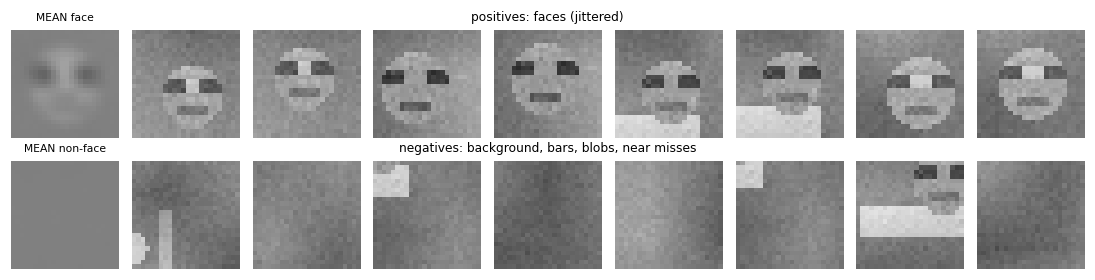

In [17]:
def build_patch_dataset(rng, n_scenes, win=24, n_faces=4, neg_per_scene=12, pos_jitter=2):
    """Cut training windows out of freshly generated scenes.

    Positives: windows centred on a face, jittered by a couple of pixels (a scanning detector
    never lands perfectly centred). Negatives: windows containing no face, including deliberate
    NEAR MISS windows a few pixels off a face, which are what teach the detector to be sharp.
    """
    X, Y, B = [], [], []
    for _ in range(n_scenes):
        specs = sample_face_specs(rng, n_faces)
        img, boxes, _ = make_scene(rng, specs)
        H, W = img.shape
        centres = [((b[0] + b[2]) / 2, (b[1] + b[3]) / 2) for b in boxes]

        def dist_to_faces(wx, wy):
            cwx, cwy = wx + win / 2, wy + win / 2
            return min([max(abs(cwx - fx), abs(cwy - fy)) for fx, fy in centres] or [1e9])

        for b in boxes:                                             # positives
            fx, fy = (b[0] + b[2]) / 2, (b[1] + b[3]) / 2
            for _ in range(2):
                wx = int(np.clip(round(fx - win / 2 + rng.integers(-pos_jitter, pos_jitter + 1)), 0, W - win))
                wy = int(np.clip(round(fy - win / 2 + rng.integers(-pos_jitter, pos_jitter + 1)), 0, H - win))
                X.append(img[wy:wy + win, wx:wx + win]); Y.append(1.0)
                B.append([((b[0] + b[2]) / 2 - wx) / win, ((b[1] + b[3]) / 2 - wy) / win,
                          (b[2] - b[0]) / win, (b[3] - b[1]) / win])
        n, guard = 0, 0
        while n < neg_per_scene and guard < 500:                    # negatives
            guard += 1
            wx, wy = int(rng.integers(0, W - win + 1)), int(rng.integers(0, H - win + 1))
            d = dist_to_faces(wx, wy)
            if d < 6:                                              # too close, that is a face
                continue
            if d < 14 and rng.random() < 0.5:                       # keep some near misses
                pass
            elif d < 14:
                continue
            X.append(img[wy:wy + win, wx:wx + win]); Y.append(0.0); B.append([0.5, 0.5, 0.7, 0.7])
            n += 1
    return np.array(X), np.array(Y), np.array(B)


t0 = time.perf_counter()
train_rng = np.random.default_rng(21)
Xtr, ytr, Btr = build_patch_dataset(train_rng, n_scenes=60, neg_per_scene=50)
test_rng = np.random.default_rng(22)
Xte, yte, Bte = build_patch_dataset(test_rng, n_scenes=20, neg_per_scene=20)
print('train: %d patches (%d faces, %d non-faces)' % (len(ytr), (ytr == 1).sum(), (ytr == 0).sum()))
print('test : %d patches (%d faces, %d non-faces)' % (len(yte), (yte == 1).sum(), (yte == 0).sum()))
print('built in %.2fs' % (time.perf_counter() - t0))

MEAN_FACE = Xtr[ytr == 1].mean(0)
fig, axes = plt.subplots(2, 9, figsize=(10, 2.6))
pos_i, neg_i = np.where(ytr == 1)[0][:8], np.where(ytr == 0)[0][:8]
axes[0, 0].imshow(MEAN_FACE, vmin=0, vmax=1); axes[0, 0].set_title('MEAN face', fontsize=7)
axes[1, 0].imshow(Xtr[ytr == 0].mean(0), vmin=0, vmax=1); axes[1, 0].set_title('MEAN non-face', fontsize=7)
for k in range(8):
    axes[0, k + 1].imshow(Xtr[pos_i[k]], vmin=0, vmax=1)
    axes[1, k + 1].imshow(Xtr[neg_i[k]], vmin=0, vmax=1)
axes[0, 4].set_title('positives: faces (jittered)', fontsize=8)
axes[1, 4].set_title('negatives: background, bars, blobs, near misses', fontsize=8)
for a in axes.ravel():
    a.axis('off')
plt.tight_layout(); plt.show()

### 6.1 The feature matrix

Precompute every candidate feature on every training patch **once**, into an
`(n_features, n_patches)` matrix. This is the step that makes the boosting loop cheap: after this,
a round of AdaBoost never touches a pixel again.

We sample **600 features** at random from the 162,336. Viola and Jones used the whole pool, and
their training ran for **weeks**. We have three minutes, so we take a random subset; the algorithm
is identical, only the pool is smaller.

In [18]:
def patch_integral_images(X):
    """Padded integral images for a stack of patches: (N, win+1, win+1)."""
    return np.pad(X.cumsum(1).cumsum(2), ((0, 0), (1, 0), (1, 0)))


def eval_features_on_patches(pool, II):
    """(n_features, n_patches) matrix of Haar responses, vectorised over patches."""
    out = np.empty((len(pool), II.shape[0]))
    for k, (t, x, y, w, h) in enumerate(pool):
        v = 0.0
        for (rx, ry, rw, rh, s) in haar_rects(t, x, y, w, h):
            v = v + s * (II[:, ry + rh, rx + rw] + II[:, ry, rx]
                         - II[:, ry, rx + rw] - II[:, ry + rh, rx])
        out[k] = v
    return out


pool_rng = np.random.default_rng(3)
POOL = [FULL_POOL[i] for i in pool_rng.choice(len(FULL_POOL), 600, replace=False)]
POOL[0], POOL[1] = EYE_FEAT, NOSE_FEAT      # make sure the two 'paper' features are candidates

t0 = time.perf_counter()
F_tr = eval_features_on_patches(POOL, patch_integral_images(Xtr))
F_te = eval_features_on_patches(POOL, patch_integral_images(Xte))
print('feature matrix %s computed in %.2fs (%d features x %d patches)'
      % (F_tr.shape, time.perf_counter() - t0, *F_tr.shape))
print('every entry took 6 to 9 integral image lookups; that is why this is instant')

# Verify the fast path against the slow path on a few random entries.
worst = max(abs(F_tr[k, i] - haar_value_naive(Xtr[i], *POOL[k]))
            for k in np.random.default_rng(0).integers(0, 600, 40)
            for i in np.random.default_rng(1).integers(0, len(Xtr), 5))
print('worst |integral image feature - naive feature| = %.2e' % worst)
assert worst < 1e-9

feature matrix (600, 3480) computed in 0.03s (600 features x 3480 patches)
every entry took 6 to 9 integral image lookups; that is why this is instant
worst |integral image feature - naive feature| = 1.24e-13


In [19]:
def adaboost_vj(F, y, T, pool=None, verbose=True):
    """Viola-Jones AdaBoost, step for step from the slide.

    F is (n_features, n_examples); pool names the features of F (defaults to the global POOL).
    """
    pool = POOL if pool is None else pool
    m, l = int((y == 0).sum()), int((y == 1).sum())
    w = np.where(y == 1, 1.0 / (2 * l), 1.0 / (2 * m))          # initialise weights
    searcher = StumpSearcher(F, y)
    feat_idx, thetas, parities, alphas = [], [], [], []
    hist = []

    for t in range(T):
        w = w / w.sum()                                          # 1. normalise
        errs, ths, pas = searcher.best(w)                        # 2. best stump per feature
        j = int(np.argmin(errs))                                 # 3. lowest error wins
        eps = max(float(errs[j]), 1e-10)
        h = stump_predict(F[j], ths[j], pas[j])
        e = (h != y).astype(float)                               # e_i = 0 if correct
        beta = eps / (1 - eps)
        w = w * beta ** (1 - e)                                  # 4. shrink the CORRECT ones
        alpha = np.log(1.0 / beta)
        feat_idx.append(j); thetas.append(ths[j]); parities.append(pas[j]); alphas.append(alpha)

        score = sum(a * stump_predict(F[jj], th, p)
                    for jj, th, p, a in zip(feat_idx, thetas, parities, alphas))
        train_err = ((score >= 0.5 * sum(alphas)).astype(float) != y).mean()
        hist.append(dict(eps=eps, alpha=alpha, feat=j, train_err=train_err))
        if verbose:
            print('  round %2d | feature %-24s eps=%.4f alpha=%.3f | strong-classifier train error %.4f'
                  % (t + 1, str(pool[j]), eps, alpha, train_err))
    return dict(feat_idx=feat_idx, thetas=thetas, parities=parities, alphas=np.array(alphas),
                feats=[pool[j] for j in feat_idx], hist=hist)


def strong_score(clf, F, T=None):
    """sum_t alpha_t h_t(x). Passing T uses only the first T rounds."""
    T = len(clf['alphas']) if T is None else T
    s = np.zeros(F.shape[1])
    for j, th, p, a in zip(clf['feat_idx'][:T], clf['thetas'][:T], clf['parities'][:T], clf['alphas'][:T]):
        s += a * stump_predict(F[j], th, p)
    return s


def strong_predict(clf, F, T=None):
    """h(x) = 1 iff sum_t alpha_t h_t(x) >= 0.5 * sum_t alpha_t."""
    T = len(clf['alphas']) if T is None else T
    return (strong_score(clf, F, T) >= 0.5 * clf['alphas'][:T].sum()).astype(float)


# Balanced subset for a clean demonstration; the cascade in section 7 uses all 3000 negatives.
sub = np.concatenate([np.where(ytr == 1)[0], np.where(ytr == 0)[0][:960]])
F_demo, y_demo = F_tr[:, sub], ytr[sub]
print('AdaBoost on %d patches (%d faces, %d non-faces), choosing from %d features:'
      % (len(y_demo), int(y_demo.sum()), int((1 - y_demo).sum()), len(POOL)))
t0 = time.perf_counter()
BOOST = adaboost_vj(F_demo, y_demo, T=25)
print('trained %d rounds in %.2fs' % (25, time.perf_counter() - t0))

AdaBoost on 1440 patches (480 faces, 960 non-faces), choosing from 600 features:


  round  1 | feature ('2h', 5, 6, 8, 6)       eps=0.0974 alpha=2.227 | strong-classifier train error 0.0868
  round  2 | feature ('2h', 9, 5, 12, 11)     eps=0.1741 alpha=1.557 | strong-classifier train error 0.0868
  round  3 | feature ('2v', 4, 9, 9, 4)       eps=0.1849 alpha=1.484 | strong-classifier train error 0.0410
  round  4 | feature ('4', 12, 8, 8, 10)      eps=0.2056 alpha=1.352 | strong-classifier train error 0.0354
  round  5 | feature ('2v', 15, 7, 3, 14)     eps=0.2260 alpha=1.231 | strong-classifier train error 0.0340
  round  6 | feature ('2h', 2, 3, 14, 8)      eps=0.2585 alpha=1.054 | strong-classifier train error 0.0340
  round  7 | feature ('2v', 4, 8, 13, 4)      eps=0.2156 alpha=1.292 | strong-classifier train error 0.0201
  round  8 | feature ('2v', 9, 5, 10, 4)      eps=0.2217 alpha=1.256 | strong-classifier train error 0.0208
  round  9 | feature ('3h', 8, 3, 3, 19)      eps=0.1736 alpha=1.560 | strong-classifier train error 0.0083
  round 10 | feature ('2v', 

  round 20 | feature ('3h', 9, 7, 15, 5)      eps=0.2485 alpha=1.107 | strong-classifier train error 0.0021


  round 21 | feature ('2v', 21, 2, 1, 10)     eps=0.2669 alpha=1.010 | strong-classifier train error 0.0014
  round 22 | feature ('2v', 6, 13, 9, 4)      eps=0.2575 alpha=1.059 | strong-classifier train error 0.0000
  round 23 | feature ('2v', 9, 19, 14, 2)     eps=0.3057 alpha=0.820 | strong-classifier train error 0.0000
  round 24 | feature ('2v', 9, 5, 10, 4)      eps=0.2769 alpha=0.960 | strong-classifier train error 0.0000
  round 25 | feature ('2h', 1, 2, 16, 19)     eps=0.2560 alpha=1.067 | strong-classifier train error 0.0000
trained 25 rounds in 0.24s


### 6.2 Does boosting actually work?

Three things to read off the figure:

* **Left: the weighted error $\epsilon_t$ of the chosen stump per round.** It starts low and then
  **climbs towards 0.5**. That is not a bug, it is the mechanism: each round re-weights the data
  towards the examples the ensemble still gets wrong, so each successive round faces a **harder,
  adversarially re-weighted problem**. When $\epsilon_t$ reaches 0.5 the stumps have nothing left to
  contribute, and $\alpha_t \to 0$ weights them out anyway.
* **Middle: the strong classifier's error.** Training error falls to **zero** even though every
  single ingredient is a barely-better-than-chance stump. Test error follows it down. This is the
  claim of the section, and it is measured, not asserted.
* **Right: the first four selected features, drawn on the mean face.** Nothing told AdaBoost what a
  face is. It was handed 600 random rectangles and it put them **on the eyes**: the early rounds all
  measure the contrast between the dark eye band and its bright surroundings, which is exactly the
  structure Viola and Jones point at. The printout below **quantifies** that concentration against
  the pool it chose from, so the claim is measured rather than admired.

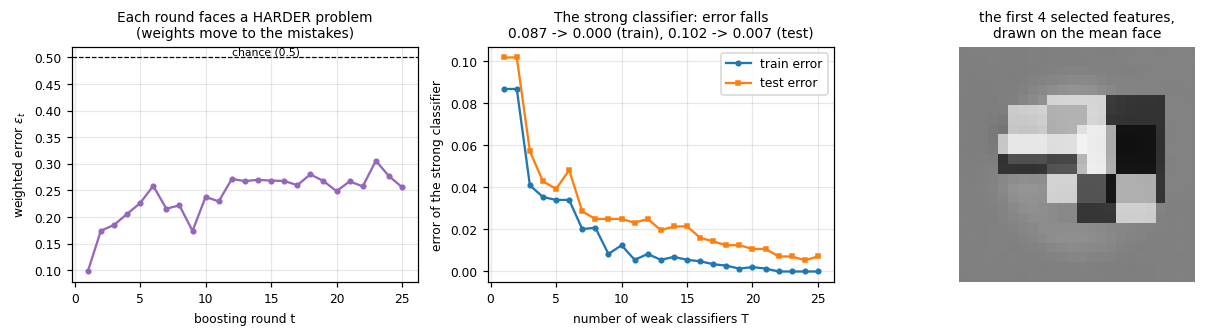

round 1 picked ('2h', 5, 6, 8, 6)      
round 2 picked ('2h', 9, 5, 12, 11)    
round 3 picked ('2v', 4, 9, 9, 4)      
round 4 picked ('4', 12, 8, 8, 10)     

fraction of features centred on the eye band (window rows 7 to 14):
  the 600-feature pool it chose FROM : 0.49   <- the baseline, by chance
  the 25 features AdaBoost SELECTED  : 0.72   <- 1.5x the baseline

T=1  weak classifier : train error 0.087
T=25 strong classifier: train error 0.000, test error 0.007


In [20]:
eps_hist = [h['eps'] for h in BOOST['hist']]
Ts = np.arange(1, 26)
tr_err = [((strong_predict(BOOST, F_demo, T) != y_demo).mean()) for T in Ts]
te_err = [((strong_predict(BOOST, F_te, T) != yte).mean()) for T in Ts]

fig = plt.figure(figsize=(11.5, 3.1))
ax = fig.add_subplot(1, 3, 1)
ax.plot(Ts, eps_hist, 'o-', ms=3, color='tab:purple')
ax.axhline(0.5, ls='--', c='k', lw=0.8); ax.text(12, 0.505, 'chance (0.5)', fontsize=7)
ax.set_xlabel('boosting round t'); ax.set_ylabel(r'weighted error $\epsilon_t$')
ax.set_title('Each round faces a HARDER problem\n(weights move to the mistakes)'); ax.grid(alpha=0.3)

ax = fig.add_subplot(1, 3, 2)
ax.plot(Ts, tr_err, 'o-', ms=3, label='train error')
ax.plot(Ts, te_err, 's-', ms=3, label='test error')
ax.set_xlabel('number of weak classifiers T'); ax.set_ylabel('error of the strong classifier')
ax.set_title('The strong classifier: error falls\n%.3f -> %.3f (train), %.3f -> %.3f (test)'
             % (tr_err[0], tr_err[-1], te_err[0], te_err[-1]))
ax.legend(); ax.grid(alpha=0.3)

ax = fig.add_subplot(1, 3, 3)
ax.imshow(MEAN_FACE, vmin=0, vmax=1)
for r, (t, x, y, w, h) in enumerate(BOOST['feats'][:4]):
    m = haar_mask(t, x, y, w, h)
    ax.imshow(np.ma.masked_where(m == 0, m), cmap='gray', vmin=-1, vmax=1, alpha=0.6)
ax.set_title('the first 4 selected features,\ndrawn on the mean face'); ax.axis('off')
plt.tight_layout(); plt.show()

for r in range(4):
    print('round %d picked %-24s' % (r + 1, str(BOOST['feats'][r])))

# Did AdaBoost really find the eyes, or does it just look that way? Measure it.
EYE_ZONE = (7, 14)          # window rows where a jittered face keeps its eye band


def in_eye_zone(feat):
    t, x, y, w, h = feat
    return EYE_ZONE[0] <= (y + h / 2) <= EYE_ZONE[1]


sel = np.mean([in_eye_zone(f) for f in BOOST['feats']])
base = np.mean([in_eye_zone(f) for f in POOL])
print('\nfraction of features centred on the eye band (window rows %d to %d):' % EYE_ZONE)
print('  the 600-feature pool it chose FROM : %.2f   <- the baseline, by chance' % base)
print('  the 25 features AdaBoost SELECTED  : %.2f   <- %.1fx the baseline' % (sel, sel / base))

print('\nT=1  weak classifier : train error %.3f' % tr_err[0])
print('T=25 strong classifier: train error %.3f, test error %.3f' % (tr_err[-1], te_err[-1]))

### 6.3 Was the selection worth anything?

The section claims AdaBoost **picks the few features that matter**. That is easy to say and easy to
test: hand AdaBoost **25 random features** instead of letting it choose 25 out of 600, and boost for
the same 25 rounds. Everything else is identical, so the only variable is the **choice**.

In [21]:
abl = []
for seed in range(5):
    idx = np.random.default_rng(seed).choice(len(POOL), 25, replace=False)
    clf = adaboost_vj(F_demo[idx], y_demo, T=25, pool=[POOL[i] for i in idx], verbose=False)
    abl.append((strong_predict(clf, F_te[idx]) != yte).mean())

print('AdaBoost CHOOSING 25 features out of %d : test error %.4f' % (len(POOL), te_err[-1]))
print('AdaBoost GIVEN 25 random features       : test error %.4f  (5 draws: %s)'
      % (np.mean(abl), np.round(abl, 3)))
print('\n-> the selection, not the boosting, is worth %.0fx in error.' % (np.mean(abl) / te_err[-1]))
print('Both runs use 25 features and 25 rounds. Only the CHOICE differs.')
print('That is why Viola and Jones reach for AdaBoost out of all the ways to combine classifiers:')
print('it is a feature selector that happens to return a classifier.')

AdaBoost CHOOSING 25 features out of 600 : test error 0.0071
AdaBoost GIVEN 25 random features       : test error 0.0482  (5 draws: [0.043 0.055 0.061 0.048 0.034])

-> the selection, not the boosting, is worth 7x in error.
Both runs use 25 features and 25 rounds. Only the CHOICE differs.
That is why Viola and Jones reach for AdaBoost out of all the ways to combine classifiers:
it is a feature selector that happens to return a classifier.


### 6.4 Interactive: how many weak classifiers do you need?

The 25 rounds are already trained, so the slider just re-slices the history and is instant. Try:

* **T = 1**: a single stump. Look at the error, then remember this is one rectangle subtraction.
* **T = 2**: the two features from the paper. The slide claims this pair reaches
  **100% detection at a 50% false positive rate**, which is precisely the first stage of the cascade
  in section 7.
* **Sweep T upwards**: watch the errors fall and the selected features spread over the face. Note
  that the cost of the classifier is **exactly T features per window**: this is the number that the
  cascade attacks.

In [22]:
def boost_explorer(T=2):
    fig = plt.figure(figsize=(10.5, 3.0))
    ax = fig.add_subplot(1, 3, 1)
    ax.plot(Ts, tr_err, '-', label='train'); ax.plot(Ts, te_err, '-', label='test')
    ax.axvline(T, color='r', lw=1.2); ax.plot([T], [tr_err[T - 1]], 'ro')
    ax.set_xlabel('T'); ax.set_ylabel('error'); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.set_title('T = %d: train %.3f, test %.3f' % (T, tr_err[T - 1], te_err[T - 1]))

    ax = fig.add_subplot(1, 3, 2)
    ax.imshow(MEAN_FACE, vmin=0, vmax=1)
    for (t, x, y, w, h) in BOOST['feats'][:T]:
        m = haar_mask(t, x, y, w, h)
        ax.imshow(np.ma.masked_where(m == 0, m), cmap='gray', vmin=-1, vmax=1, alpha=0.75)
    ax.set_title('the %d selected features' % T); ax.axis('off')

    ax = fig.add_subplot(1, 3, 3)
    sc = strong_score(BOOST, F_demo, T) / max(BOOST['alphas'][:T].sum(), 1e-9)
    ax.hist(sc[y_demo == 0], bins=30, alpha=0.65, label='non-faces', color='tab:red')
    ax.hist(sc[y_demo == 1], bins=30, alpha=0.65, label='faces', color='tab:green')
    ax.axvline(0.5, color='k', ls='--', lw=1)
    ax.set_xlabel(r'normalised score $\sum \alpha_t h_t / \sum \alpha_t$'); ax.set_ylabel('count')
    ax.set_title('score histogram (dashed = the 1/2 threshold)'); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()
    print('cost of this classifier: %d Haar features per window (about %d integral image lookups)'
          % (T, T * 7))


interact(boost_explorer, T=IntSlider(value=2, min=1, max=25, step=1, description='T rounds'));

interactive(children=(IntSlider(value=2, description='T rounds', max=25, min=1), Output()), _dom_classes=('wid…

---
## 7. The classifier cascade

**Intuition** (straight from the slide):

* **Very few sub-windows actually contain an object.** In a typical image, essentially every window
  is background.
* But **computation is equal across all sub-windows**: the classifier of section 6 spends the same
  25 features on an obvious patch of sky as on a face.
* So **eliminate negative windows earlier**, and stop spending time on them.

**Why it matters: the arithmetic forces it.**

* A 1 MP image has $\sim 10^6$ pixels and a comparable number of candidate face locations, so to
  avoid drowning the image in false positives our **FP rate must be below $10^{-6}$**.
* The two-feature combination from section 6.3 gives **100% detection at a 50% FP rate**: useless
  alone, but it is nearly free and it throws away half the image.
* A 200-feature classifier reaches a 95% detection rate at an FP rate of **1 in 14084**. **Not
  enough!** That is $7 \times 10^{-5}$, still two orders of magnitude short, and it costs 200
  features on every single window.

**The cascade.** Chain classifiers so that a window must survive **every** stage. Then the rates
**multiply**:

$$D = \prod_{k=1}^{K} d_k \qquad\qquad F = \prod_{k=1}^{K} f_k$$

This is the trick, because the two products behave completely differently:

* A detection rate of **0.9** and an FP rate of order $10^{-6}$ come from a **10-stage cascade** with
  $d_k = 0.99$ and $f_k = 0.30$ per stage: $0.99^{10} \approx 0.9$ and $0.3^{10} \approx 6 \times 10^{-6}$.
* Each stage only has to be **mediocre** (reject 70% of negatives, keep 99% of faces). Multiplying
  ten mediocre stages gives an excellent detector.
* And the **cost** collapses, because a negative window that dies in stage 1 never pays for stages
  2 to 10. Expected features per window: $\;\mathbb{E}[\text{cost}] = \sum_{k} n_k \prod_{j<k} f_j$.

In [23]:
def cascade_calculator(n_stages=10, stage_det=0.99, stage_fp=0.30, feats_per_stage=20):
    k = np.arange(1, n_stages + 1)
    D, Fp = stage_det ** k, stage_fp ** k
    exp_cost = np.cumsum(feats_per_stage * stage_fp ** (k - 1))     # sum_k n_k * prod_{j<k} f_j
    flat_cost = feats_per_stage * k

    fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.2))
    ax = axes[0]
    ax.plot(k, D, 'o-', color='tab:green', label='detection rate  $D = d^K$')
    ax.plot(k, Fp, 's-', color='tab:red', label='false positive rate  $F = f^K$')
    ax.axhline(1e-6, ls='--', c='k', lw=0.9)
    ax.text(1, 1.4e-6, 'target: FP < $10^{-6}$ (1 MP image)', fontsize=7)
    ax.set_yscale('log'); ax.set_ylim(1e-9, 2); ax.set_xlabel('number of stages K')
    ax.set_title('Rates MULTIPLY across stages'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

    ax = axes[1]
    ax.plot(k, flat_cost, 'o--', color='gray', label='no cascade (every stage on every window)')
    ax.plot(k, exp_cost, 'o-', color='tab:blue', label='cascade (expected)')
    ax.set_xlabel('number of stages K'); ax.set_ylabel('features evaluated per window')
    ax.set_title('and the COST does not'); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    print('K = %d stages, each with detection rate %.3f and FP rate %.3f, %d features per stage'
          % (n_stages, stage_det, stage_fp, feats_per_stage))
    print('  overall detection rate : %.4f   (%.3f^%d)' % (D[-1], stage_det, n_stages))
    print('  overall FP rate        : %.3e   (%.3f^%d)   %s the 1e-6 target'
          % (Fp[-1], stage_fp, n_stages, 'MEETS' if Fp[-1] < 1e-6 else 'MISSES'))
    print('  expected features/window: %.1f  vs  %d without the cascade  -> %.1fx cheaper'
          % (exp_cost[-1], flat_cost[-1], flat_cost[-1] / exp_cost[-1]))


interact(cascade_calculator,
         n_stages=IntSlider(value=10, min=1, max=30, step=1, description='K stages'),
         stage_det=FloatSlider(value=0.99, min=0.90, max=1.0, step=0.005, description='$d_k$', readout_format='.3f'),
         stage_fp=FloatSlider(value=0.30, min=0.05, max=0.9, step=0.05, description='$f_k$'),
         feats_per_stage=IntSlider(value=20, min=1, max=100, step=1, description='feats/stage'));

interactive(children=(IntSlider(value=10, description='K stages', max=30, min=1), FloatSlider(value=0.99, desc…

### 7.1 How many features does one stage need?

Before training a cascade we have to size its stages, and a cascade stage has a strange job: **keep
essentially every face, and reject as much as possible of everything else**. That asymmetry puts a
hard floor under the number of features per stage, for a reason that is easy to miss:

* A strong classifier of $T$ stumps outputs $\sum_t \alpha_t h_t(x)$, and each $h_t \in \{0, 1\}$.
  So the score takes **at most $2^T$ distinct values**, and the threshold has **at most $2^T$
  useful places to sit**.
* With $T = 1$ there are exactly **two** operating points: accept everything, or accept only what
  the single stump likes. If a few percent of faces fall on the wrong side of that stump, then
  demanding a 99.5% detection rate forces the threshold below **every** negative's score too, and
  the stage rejects **nothing**.
* So a stage that is too small is not merely weak, it is **useless**: it cannot trade at all.

The table below measures the real trade-off on our data, by taking prefixes of one boosted
classifier. Read it as the **design space of a stage**: pick a row, and it tells you the price.

In [24]:
def stage_operating_point(clf, F, y, T, target_det):
    """Threshold a T-feature stage to keep target_det of the faces, and report what it costs."""
    sp, sn = strong_score(clf, F[:, y == 1], T), strong_score(clf, F[:, y == 0], T)
    thr = float(np.quantile(sp, 1 - target_det)) - 1e-9
    return float((sp >= thr).mean()), float((sn >= thr).mean())


probe = adaboost_vj(F_tr, ytr, T=8, verbose=False)          # train once, then read its prefixes

print('A stage of T features, thresholded to keep a target fraction of the faces.')
print('Each entry is the resulting FP rate: the non-faces the stage still lets through.\n')
targets = (1.0, 0.995, 0.99, 0.98)
print('%-4s %-12s %s' % ('T', 'max scores', '  '.join('det>=%.3f' % t for t in targets)))
print('-' * 56)
for T in range(1, 9):
    cells = ['%9.2f' % stage_operating_point(probe, F_tr, ytr, T, t)[1] for t in targets]
    print('%-4d %-12d %s' % (T, 2 ** T, '  '.join(cells)))

d3, f3 = stage_operating_point(probe, F_tr, ytr, 3, 0.995)
print('\nRead the T=1 and T=2 rows: at a 99.5% detection rate they reject NOTHING (FP = 1.00).')
print('There are not enough distinct score values to fit a threshold between the classes.')
print('At T=3 we get detection %.3f at an FP rate of %.2f: that is our stage 1.' % (d3, f3))
print('\nThe paper gets 100% detection at a 50% FP rate from just TWO features. We need three,')
print('because their training faces are tightly ALIGNED while ours are jittered and vary in size.')
print('Aligned data buys a cheaper stage 1: a lesson about the data, not about the code.')

A stage of T features, thresholded to keep a target fraction of the faces.
Each entry is the resulting FP rate: the non-faces the stage still lets through.

T    max scores   det>=1.000  det>=0.995  det>=0.990  det>=0.980
--------------------------------------------------------
1    2                 1.00       1.00       1.00       1.00
2    4                 1.00       1.00       1.00       0.11
3    8                 1.00       0.47       0.47       0.09
4    16                0.52       0.47       0.12       0.08
5    32                0.27       0.25       0.09       0.07
6    64                0.26       0.11       0.09       0.06
7    128               0.07       0.07       0.06       0.04
8    256               0.07       0.06       0.06       0.03

Read the T=1 and T=2 rows: at a 99.5% detection rate they reject NOTHING (FP = 1.00).
There are not enough distinct score values to fit a threshold between the classes.
At T=3 we get detection 0.998 at an FP rate of 0.47: that is ou

### 7.2 The machinery: scanning an image with a cascade

Two functions. The first evaluates **one Haar feature at every window position at once**, from a
**single integral image of the whole image**: this is the payoff of section 4, and it is why the
detector never re-crops anything. The second walks the stages, and the important line is
`alive = alive[score >= threshold]`: after each stage we **keep only the survivors**, so the next
stage's work shrinks. That one line is the cascade.

In [25]:
def eval_feature_windows(II, feat, xs, ys):
    """Evaluate one Haar feature for MANY windows at once, from ONE integral image of the image."""
    t, x, y, w, h = feat
    v = 0.0
    for (rx, ry, rw, rh, s) in haar_rects(t, x, y, w, h):
        y0, x0, y1, x1 = ys + ry, xs + rx, ys + ry + rh, xs + rx + rw
        v = v + s * (II[y1, x1] + II[y0, x0] - II[y0, x1] - II[y1, x0])
    return v


def cascade_scan(img, cascade, win=24, stride=2):
    """Slide the cascade over an image. Returns surviving windows, the funnel and the cost."""
    II = integral_image(img)
    H, W = img.shape
    gy, gx = np.mgrid[0:H - win + 1:stride, 0:W - win + 1:stride]
    xs, ys = gx.ravel(), gy.ravel()
    alive = np.arange(len(xs))
    funnel, n_feat_evals = [len(alive)], 0
    for clf in cascade:
        if len(alive) == 0:
            funnel.append(0); continue
        score = np.zeros(len(alive))
        for feat, th, p, a in zip(clf['feats'], clf['thetas'], clf['parities'], clf['alphas']):
            v = eval_feature_windows(II, feat, xs[alive], ys[alive])
            score += a * (p * v < p * th)
            n_feat_evals += len(alive)                    # count EVERY feature evaluation
        alive = alive[score >= clf['threshold']]          # <- the cascade, in one line
        funnel.append(len(alive))
    boxes = np.stack([xs[alive], ys[alive], xs[alive] + win, ys[alive] + win], 1).astype(float)
    scores = np.zeros(len(alive))
    if len(alive) and cascade:                            # final stage score, used later by NMS
        c = cascade[-1]
        for feat, th, p, a in zip(c['feats'], c['thetas'], c['parities'], c['alphas']):
            scores += a * (p * eval_feature_windows(II, feat, xs[alive], ys[alive]) < p * th)
    return boxes, scores, funnel, n_feat_evals


print('scanning machinery ready')

scanning machinery ready


### 7.3 Training a real cascade, with bootstrapping

Not a simulation: we train **4 real stages** of AdaBoost.

* **Stage 1 gets 3 features** (the paper uses 2; see the table above for why we need one more). It is
  almost free, and its job is simply to delete the easy half of the image.
* Stages grow: **3, then 5, then 8, then 15** features. Cheap tests first, expensive tests only on
  the survivors. The ordering is the whole design: see exercise 1.
* Each stage's threshold is **lowered** from the default $\frac12\sum\alpha_t$ until it keeps
  **99.5% of the faces**. A cascade stage must almost never reject a face: a face lost in stage 1
  can never be recovered downstream, whereas a false positive can still be killed by a later stage.
  This is a deliberately **asymmetric** trade, and it is why we tune the threshold at all.

**Bootstrapping**, which is the part everyone forgets: a stage may only train on the negatives that
**reach** it. So before each stage we **scan face-free scenes with the cascade built so far and
collect the windows it still accepts**. Every one of those is a false positive, and they are the
only negatives the next stage can learn anything from.

* Random background crops would be useless by stage 3: the earlier stages already reject almost all
  of them, so they carry no gradient, no information, nothing.
* Watch the **"scenes scanned"** column climb. Each stage rejects more, so **finding a hard negative
  gets exponentially more expensive**. That single effect is why Viola and Jones report training
  times measured in **weeks**, and why our cascade stops at 4 stages rather than their 38.

In [26]:
def mine_negatives(cascade, rng, n_needed, win=24, max_scenes=45, stride=4):
    """Viola-Jones bootstrapping: scan FACE-FREE scenes with the cascade so far and keep the
    windows it still accepts. Those false positives are this stage's training negatives."""
    out, scenes = [], 0
    while len(out) < n_needed and scenes < max_scenes:
        img, _, _ = make_scene(rng, [])                       # a scene with no faces at all
        scenes += 1
        boxes, _, _, _ = cascade_scan(img, cascade, win=win, stride=stride)
        for (x0, y0) in boxes[:, :2].astype(int):
            out.append(img[y0:y0 + win, x0:x0 + win])
    return np.array(out[:n_needed]), scenes


def train_cascade(F_pos, stage_T=(3, 5, 8, 15), target_det=0.995, n_neg=2500, seed=99):
    """Train a cascade, mining fresh hard negatives for every stage."""
    stages, rng = [], np.random.default_rng(seed)
    for si, T in enumerate(stage_T):
        Xneg, scenes = mine_negatives(stages, rng, n_neg)          # <- bootstrapping
        F_neg = eval_features_on_patches(POOL, patch_integral_images(Xneg))
        Fs = np.concatenate([F_pos, F_neg], 1)
        ys = np.concatenate([np.ones(F_pos.shape[1]), np.zeros(F_neg.shape[1])])
        clf = adaboost_vj(Fs, ys, T, verbose=False)

        sp, sn = strong_score(clf, F_pos), strong_score(clf, F_neg)
        default_thr = 0.5 * clf['alphas'].sum()
        thr = float(np.quantile(sp, 1 - target_det)) - 1e-9        # keep target_det of the faces
        clf['threshold'] = thr
        stages.append(clf)
        print('stage %d | %2d features | %4d hard negatives mined from %2d face-free scenes'
              % (si + 1, T, len(Xneg), scenes))
        print('          default threshold (0.5*sum alpha): detection %.3f, FP %.3f'
              % ((sp >= default_thr).mean(), (sn >= default_thr).mean()))
        print('          tuned threshold  (keep %.1f%% faces): detection %.3f, FP %.3f  <- used'
              % (100 * target_det, (sp >= thr).mean(), (sn >= thr).mean()))
    return stages


t0 = time.perf_counter()
CASCADE = train_cascade(F_tr[:, ytr == 1])
print('\ncascade trained in %.2fs' % (time.perf_counter() - t0))

# A window must survive EVERY stage, so the overall rates are the product of the stage rates.
alive_te = np.ones(F_te.shape[1], bool)
stage_rates = []
for c in CASCADE:
    passed = strong_score(c, F_te) >= c['threshold']
    stage_rates.append((float(passed[(yte == 1) & alive_te].mean()),
                        float(passed[(yte == 0) & alive_te].mean())))
    alive_te &= passed
print('\nheld-out test set, per stage (measured on the windows still alive):')
for i, (d, f) in enumerate(stage_rates):
    print('  stage %d: detection rate %.3f, FP rate %.3f' % (i + 1, d, f))
print('  cascade: detection rate %.3f, FP rate %.3f'
      % (alive_te[yte == 1].mean(), alive_te[yte == 0].mean()))
print('  product of the stage rates: detection %.3f, FP %.3f  <- the rates multiply'
      % (np.prod([d for d, f in stage_rates]), np.prod([f for d, f in stage_rates])))
print('\ntotal cost if a window survives everything: %d features' % sum(len(c["alphas"]) for c in CASCADE))

stage 1 |  3 features | 2500 hard negatives mined from  3 face-free scenes
          default threshold (0.5*sum alpha): detection 0.952, FP 0.074
          tuned threshold  (keep 99.5% faces): detection 0.998, FP 0.480  <- used


stage 2 |  5 features | 2500 hard negatives mined from  6 face-free scenes
          default threshold (0.5*sum alpha): detection 0.917, FP 0.034
          tuned threshold  (keep 99.5% faces): detection 0.996, FP 0.171  <- used


stage 3 |  8 features | 2500 hard negatives mined from 34 face-free scenes
          default threshold (0.5*sum alpha): detection 0.881, FP 0.046
          tuned threshold  (keep 99.5% faces): detection 0.994, FP 0.243  <- used
stage 4 | 15 features |  825 hard negatives mined from 45 face-free scenes
          default threshold (0.5*sum alpha): detection 0.969, FP 0.012
          tuned threshold  (keep 99.5% faces): detection 0.994, FP 0.088  <- used

cascade trained in 0.77s

held-out test set, per stage (measured on the windows still alive):
  stage 1: detection rate 1.000, FP rate 0.495
  stage 2: detection rate 0.975, FP rate 0.192
  stage 3: detection rate 0.994, FP rate 0.263
  stage 4: detection rate 0.981, FP rate 0.200
  cascade: detection rate 0.950, FP rate 0.005
  product of the stage rates: detection 0.950, FP 0.005  <- the rates multiply

total cost if a window survives everything: 31 features


### 7.4 The cascade on a real scan: the funnel

Now point the cascade at the canvas. We scan **every 24x24 window at stride 2** and count how many
survive each stage. This is the measurement the whole section is about: **how much compute does the
cascade actually save?**

Note the last cell prints the **average number of features per window**, measured, not modelled.

In [27]:
t0 = time.perf_counter()
VJ_BOXES, VJ_SCORES, FUNNEL, N_EVALS = cascade_scan(CANVAS, CASCADE, stride=2)
scan_t = time.perf_counter() - t0

n_win = FUNNEL[0]
total_feats = sum(len(c['alphas']) for c in CASCADE)
print('scanned %d windows of the %dx%d canvas in %.3fs\n' % (n_win, *CANVAS.shape[::-1], scan_t))
print('%-28s %10s %12s' % ('', 'surviving', '% of input'))
print('all sub-windows              %10d %11.1f%%' % (FUNNEL[0], 100.0))
for i, c in enumerate(CASCADE):
    print('after stage %d (%2d features) %10d %11.1f%%'
          % (i + 1, len(c['alphas']), FUNNEL[i + 1], 100 * FUNNEL[i + 1] / n_win))
print('\nfeature evaluations actually performed : %d' % N_EVALS)
print('average features per window            : %.2f' % (N_EVALS / n_win))
print('cost without the cascade               : %d per window (%d total)' % (total_feats, total_feats * n_win))
print('MEASURED SPEEDUP                       : %.1fx' % (total_feats * n_win / N_EVALS))
print('\nStage 1 alone rejects %.1f%% of the image using %d rectangle features.'
      % (100 * (1 - FUNNEL[1] / n_win), len(CASCADE[0]['alphas'])))

scanned 3381 windows of the 160x120 canvas in 0.002s

                              surviving   % of input
all sub-windows                    3381       100.0%
after stage 1 ( 3 features)       2071        61.3%
after stage 2 ( 5 features)        536        15.9%
after stage 3 ( 8 features)        190         5.6%
after stage 4 (15 features)         42         1.2%

feature evaluations actually performed : 27636
average features per window            : 8.17
cost without the cascade               : 31 per window (104811 total)
MEASURED SPEEDUP                       : 3.8x

Stage 1 alone rejects 38.7% of the image using 3 rectangle features.


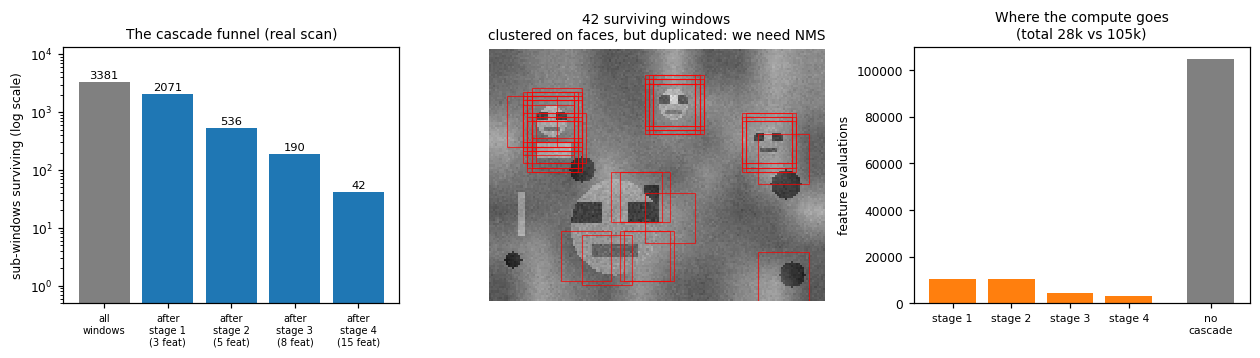

The funnel is the point: 3381 windows in, 42 out, and most died against 3 features.
Panel 2 is the next problem: each face fires several overlapping windows.


In [28]:
fig = plt.figure(figsize=(11.5, 3.3))

# Panel 1: the funnel.
ax = fig.add_subplot(1, 3, 1)
labels = ['all\nwindows'] + ['after\nstage %d\n(%d feat)' % (i + 1, len(c['alphas']))
                             for i, c in enumerate(CASCADE)]
bars = ax.bar(range(len(FUNNEL)), FUNNEL, color=['gray'] + ['tab:blue'] * len(CASCADE))
for i, v in enumerate(FUNNEL):
    ax.text(i, max(v, 0.6) * 1.15, '%d' % v, ha='center', fontsize=7.5)
ax.set_yscale('log'); ax.set_ylim(0.5, FUNNEL[0] * 4)
ax.set_xticks(range(len(FUNNEL))); ax.set_xticklabels(labels, fontsize=6.5)
ax.set_ylabel('sub-windows surviving (log scale)'); ax.set_title('The cascade funnel (real scan)')

# Panel 2: where the survivors are.
ax = fig.add_subplot(1, 3, 2)
ax.imshow(CANVAS, vmin=0, vmax=1)
for b in VJ_BOXES:
    ax.add_patch(mpatches.Rectangle((b[0], b[1]), 24, 24, fill=False, ec='red', lw=0.7, alpha=0.7))
ax.set_title('%d surviving windows\nclustered on faces, but duplicated: we need NMS' % len(VJ_BOXES))
ax.axis('off')

# Panel 3: where the compute went.
ax = fig.add_subplot(1, 3, 3)
per_stage = [len(c['alphas']) * FUNNEL[i] for i, c in enumerate(CASCADE)]
ax.bar(range(1, len(CASCADE) + 1), per_stage, color='tab:orange')
ax.bar([len(CASCADE) + 1.4], [total_feats * n_win], color='gray')
ax.set_xticks(list(range(1, len(CASCADE) + 1)) + [len(CASCADE) + 1.4])
ax.set_xticklabels(['stage %d' % (i + 1) for i in range(len(CASCADE))] + ['no\ncascade'], fontsize=7)
ax.set_ylabel('feature evaluations'); ax.set_title('Where the compute goes\n(total %.0fk vs %.0fk)'
                                                   % (N_EVALS / 1e3, total_feats * n_win / 1e3))
plt.tight_layout(); plt.show()

print('The funnel is the point: %d windows in, %d out, and most died against %d features.'
      % (FUNNEL[0], FUNNEL[-1], len(CASCADE[0]['alphas'])))
print('Panel 2 is the next problem: each face fires several overlapping windows.')

---
## 8. Intersection over Union (IoU)

Panel 2 of the last figure is the problem: **more than one bounding box is detected for the same
object**. To remove the duplicates we first need a **similarity measure between boxes**.

$$IoU = \frac{B_1 \cap B_2}{B_1 \cup B_2} = \frac{\text{area of overlap}}{\text{area of union}}$$

* IoU is a **ratio**, so it is scale invariant: two boxes twice as big with twice the overlap score
  the same. A raw overlap area could not be compared between a face and a bus.
* It is 1 for identical boxes and 0 for disjoint boxes, so it is a drop-in "are these the same
  detection?" test. A threshold of **0.5** is the convention used throughout detection.
* The one subtlety in the implementation is the union. Do **not** add the two areas: the overlap
  would be counted twice. Inclusion-exclusion gives

$$|B_1 \cup B_2| = |B_1| + |B_2| - |B_1 \cap B_2|$$

* The intersection of two axis-aligned boxes is itself an axis-aligned box, with corners
  $\max$ of the left/top edges and $\min$ of the right/bottom edges. If either side comes out
  negative the boxes do not overlap, hence the **clamp at zero**, which is the bug everyone writes
  the first time.

In [29]:
def iou(a, b):
    """IoU of two boxes in (x1, y1, x2, y2) format."""
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])          # intersection: max of the near edges
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])          # min of the far edges
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)    # clamp: negative means no overlap
    inter = iw * ih
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union = area_a + area_b - inter                      # inclusion-exclusion, not a + b
    return inter / union if union > 0 else 0.0


def iou_batch(box, boxes):
    """Vectorised IoU of one box against many. Same formula, no python loop."""
    if len(boxes) == 0:
        return np.zeros(0)
    ix1 = np.maximum(box[0], boxes[:, 0]); iy1 = np.maximum(box[1], boxes[:, 1])
    ix2 = np.minimum(box[2], boxes[:, 2]); iy2 = np.minimum(box[3], boxes[:, 3])
    inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
    area = (box[2] - box[0]) * (box[3] - box[1])
    areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    return inter / (area + areas - inter)


def iou_reference(a, b):
    """The slow, obviously correct reference: rasterise both boxes and count pixels.

    Exact for integer boxes, because a half-open pixel range [x1, x2) holds exactly x2 - x1 pixels.
    """
    a = [int(v) for v in a]; b = [int(v) for v in b]
    W = max(a[2], b[2]) + 1; H = max(a[3], b[3]) + 1
    m1 = np.zeros((H, W), bool); m1[a[1]:a[3], a[0]:a[2]] = True
    m2 = np.zeros((H, W), bool); m2[b[1]:b[3], b[0]:b[2]] = True
    union = (m1 | m2).sum()
    return (m1 & m2).sum() / union if union else 0.0


# Verify the formula against the pixel counter on 2000 random box pairs.
rng_i = np.random.default_rng(7)
worst = 0.0
for _ in range(2000):
    p = np.sort(rng_i.integers(0, 40, 2)); q = np.sort(rng_i.integers(0, 40, 2))
    r = np.sort(rng_i.integers(0, 40, 2)); s = np.sort(rng_i.integers(0, 40, 2))
    if p[0] == p[1] or q[0] == q[1] or r[0] == r[1] or s[0] == s[1]:
        continue
    A, B = [p[0], q[0], p[1], q[1]], [r[0], s[0], r[1], s[1]]
    worst = max(worst, abs(iou(A, B) - iou_reference(A, B)))
print('worst |formula IoU - pixel-counted IoU| over 2000 random pairs = %.2e' % worst)
assert worst < 1e-9
print('identical boxes  : IoU = %.2f' % iou([0, 0, 10, 10], [0, 0, 10, 10]))
print('disjoint boxes   : IoU = %.2f' % iou([0, 0, 10, 10], [50, 50, 60, 60]))
print('half overlap     : IoU = %.4f  (inter 50, union 150)' % iou([0, 0, 10, 10], [5, 0, 15, 10]))
print('one inside other : IoU = %.2f  (a small box inside a big one scores LOW)'
      % iou([0, 0, 10, 10], [0, 0, 5, 5]))

worst |formula IoU - pixel-counted IoU| over 2000 random pairs = 0.00e+00
identical boxes  : IoU = 1.00
disjoint boxes   : IoU = 0.00
half overlap     : IoU = 0.3333  (inter 50, union 150)
one inside other : IoU = 0.25  (a small box inside a big one scores LOW)


### 8.1 Interactive: build an intuition for the number

Drag box 2 around and watch IoU. Two things are worth internalising, because they explain a lot of
detector behaviour:

* **IoU falls off fast.** Two boxes of the same size offset by only **a third of their width**
  already drop to about 0.5. IoU is a much harsher judge than it looks.
* **Nesting is punished.** A small box perfectly inside a large one has IoU = (small/large), so a
  detection that is correct but too loose scores badly. This is the quantitative version of the
  "loosely bound" complaint in section 11, and the reason box regression exists.

In [30]:
def iou_demo(dx=14, dy=6, size=30):
    A = [10.0, 10.0, 40.0, 40.0]
    B = [10.0 + dx, 10.0 + dy, 10.0 + dx + size, 10.0 + dy + size]
    v = iou(A, B)
    ix1, iy1 = max(A[0], B[0]), max(A[1], B[1])
    ix2, iy2 = min(A[2], B[2]), min(A[3], B[3])

    fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.2), gridspec_kw={'width_ratios': [1.15, 1]})
    ax = axes[0]
    if ix2 > ix1 and iy2 > iy1:
        ax.add_patch(mpatches.Rectangle((ix1, iy1), ix2 - ix1, iy2 - iy1, fc='tab:blue', alpha=0.55))
    ax.add_patch(mpatches.Rectangle((A[0], A[1]), A[2] - A[0], A[3] - A[1], fill=False, ec='red', lw=2))
    ax.add_patch(mpatches.Rectangle((B[0], B[1]), B[2] - B[0], B[3] - B[1], fill=False, ec='red', lw=2))
    ax.text(A[0], A[1] - 1.5, '$B_1$', color='red'); ax.text(B[0], B[3] + 4, '$B_2$', color='red')
    ax.set_xlim(0, 90); ax.set_ylim(90, 0); ax.set_aspect('equal'); ax.axis('off')
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = 30 * 30 + size * size - inter
    ax.set_title('intersection = %.0f, union = %.0f\nIoU = %.0f / %.0f = %.3f' % (inter, union, inter, union, v))

    ax = axes[1]
    ax.barh([0], [v], color=('tab:green' if v > 0.5 else 'tab:red'), height=0.4)
    ax.axvline(0.5, ls='--', c='k'); ax.text(0.51, 0.28, 'NMS threshold 0.5', fontsize=7)
    ax.set_xlim(0, 1); ax.set_yticks([]); ax.set_xlabel('IoU')
    ax.set_title('%s' % ('SAME object -> suppress' if v > 0.5 else 'DIFFERENT objects -> keep'))
    plt.tight_layout(); plt.show()


interact(iou_demo, dx=IntSlider(value=14, min=-40, max=40, step=1, description='shift x'),
         dy=IntSlider(value=6, min=-40, max=40, step=1, description='shift y'),
         size=IntSlider(value=30, min=5, max=60, step=1, description='size of $B_2$'));

interactive(children=(IntSlider(value=14, description='shift x', max=40, min=-40), IntSlider(value=6, descript…

---
## 9. Non-Maximum Suppression

The slide gives the algorithm in three lines:

* Select a **random** box from the bounding box proposal list
* Compare it with the rest of the boxes; if **IoU > 0.5**, remove that box from the list
* Repeat until the boxes left are exclusive

and then, a few slides later, quietly fixes it: **identify the box with the highest class signal**
(0.93 red), then eliminate the boxes with IoU > 0.5 with respect to it. That upgrade is the whole
idea, and it is what "non-**maximum** suppression" means:

* With a **random** pick, each cluster survives as an arbitrary member. The kept box is as likely to
  be the sloppiest box in the cluster as the best one.
* With the **highest scoring** pick, the survivor of each cluster is the box the classifier is most
  confident about. Everything suppressed is a **non-maximum**, hence the name.
* It is **greedy**: take the max, suppress its neighbourhood, repeat on what is left. There is no
  optimisation and no training, and it is still what almost every detector does today.

We implement both and measure the difference rather than asserting it.

In [31]:
def nms(boxes, scores, iou_thresh=0.5):
    """Greedy NMS: take the highest scoring box, suppress everything that overlaps it, repeat."""
    order = np.argsort(-scores)                       # highest score first: the 'maximum'
    keep = []
    while len(order) > 0:
        i = order[0]                                  # the current maximum survives
        keep.append(i)
        rest = order[1:]
        if len(rest) == 0:
            break
        order = rest[iou_batch(boxes[i], boxes[rest]) <= iou_thresh]     # suppress its neighbours
    return np.array(keep, int)


def nms_random_order(boxes, scores, iou_thresh, rng):
    """The slide's FIRST description: pick a RANDOM box instead of the best one."""
    order = rng.permutation(len(boxes))
    keep = []
    while len(order) > 0:
        i = order[0]
        keep.append(i)
        rest = order[1:]
        if len(rest) == 0:
            break
        order = rest[iou_batch(boxes[i], boxes[rest]) <= iou_thresh]
    return np.array(keep, int)


def best_iou_to_gt(boxes, gt):
    """For each ground truth box, the IoU of the best matching detection."""
    return np.array([max([iou(g, b) for b in boxes] or [0.0]) for g in gt])


MATCH_IOU = 0.3        # see the note below on why this is not the usual 0.5

keep = nms(VJ_BOXES, VJ_SCORES, 0.5)
print('Viola-Jones raw output : %d boxes' % len(VJ_BOXES))
print('after greedy NMS       : %d boxes' % len(keep))
print('ground truth           : %d faces (one is 48px, too big for a 24x24 window)' % len(CANVAS_BOXES))

# Does the ordering actually matter? Measure it two ways over 200 random orders.
best_box = int(np.argmax(VJ_SCORES))                       # the single most confident detection
rng_n = np.random.default_rng(5)
surv, meansc = [], []
for _ in range(200):
    k_rand = nms_random_order(VJ_BOXES, VJ_SCORES, 0.5, rng_n)
    surv.append(best_box in set(k_rand.tolist()))
    meansc.append(VJ_SCORES[k_rand].mean())

print('\n%-38s %10s %10s' % ('', 'score-order', 'random-order'))
print('%-38s %10.2f %10.2f' % ('mean score of the surviving boxes',
                               VJ_SCORES[keep].mean(), float(np.mean(meansc))))
print('%-38s %10.0f%% %9.0f%%' % ('the top-scoring box survives',
                                  100.0, 100 * float(np.mean(surv))))
print('\nRandom order throws away the best box %.0f%% of the time: a neighbour gets picked first'
      % (100 * (1 - float(np.mean(surv)))))
print('and suppresses it. Score order keeps every cluster MAXIMUM by construction, which is')
print('what the name says and why the slide switches to the highest class signal.')
print('\nNOTE those IoU values. A 24x24 window on a 16px face caps out at 16^2/24^2 = %.2f,'
      % (16 ** 2 / 24 ** 2))
print('so even a PERFECT detection fails the standard IoU > 0.5 test. The boxes are too loose.')
print('That is not a bug in NMS: it is disadvantage 1 of sliding windows (section 13),')
print('and section 14 fixes it with box regression. Until then we match at IoU > %.1f.' % MATCH_IOU)

Viola-Jones raw output : 42 boxes
after greedy NMS       : 12 boxes
ground truth           : 4 faces (one is 48px, too big for a 24x24 window)

                                       score-order random-order
mean score of the surviving boxes            7.47       7.01
the top-scoring box survives                  100%         8%

Random order throws away the best box 92% of the time: a neighbour gets picked first
and suppresses it. Score order keeps every cluster MAXIMUM by construction, which is
what the name says and why the slide switches to the highest class signal.

NOTE those IoU values. A 24x24 window on a 16px face caps out at 16^2/24^2 = 0.44,
so even a PERFECT detection fails the standard IoU > 0.5 test. The boxes are too loose.
That is not a bug in NMS: it is disadvantage 1 of sliding windows (section 13),
and section 14 fixes it with box regression. Until then we match at IoU > 0.3.


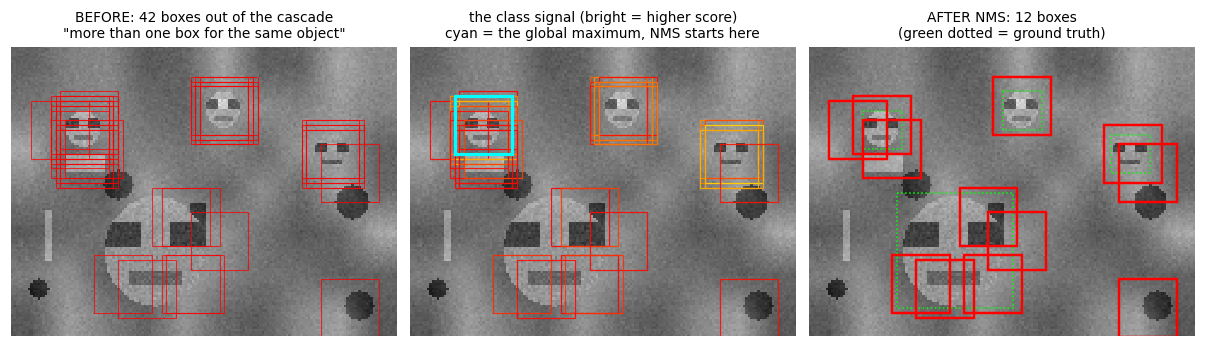

That is a complete Viola-Jones detector: Haar + integral image + AdaBoost + cascade + NMS.
It misses the 48px face, as designed: a 24x24 window cannot see it. Section 10 fixes that.


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

axes[0].imshow(CANVAS, vmin=0, vmax=1)
for b in VJ_BOXES:
    axes[0].add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1],
                                         fill=False, ec='red', lw=0.7, alpha=0.75))
axes[0].set_title('BEFORE: %d boxes out of the cascade\n"more than one box for the same object"'
                  % len(VJ_BOXES))

sc = (VJ_SCORES - VJ_SCORES.min()) / (np.ptp(VJ_SCORES) + 1e-9)
axes[1].imshow(CANVAS, vmin=0, vmax=1)
for b, s in zip(VJ_BOXES, sc):
    axes[1].add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1],
                                         fill=False, ec=plt.cm.autumn(s), lw=0.8, alpha=0.9))
best = np.argmax(VJ_SCORES)
axes[1].add_patch(mpatches.Rectangle((VJ_BOXES[best][0], VJ_BOXES[best][1]), 24, 24,
                                     fill=False, ec='cyan', lw=2))
axes[1].set_title('the class signal (bright = higher score)\ncyan = the global maximum, NMS starts here')

axes[2].imshow(CANVAS, vmin=0, vmax=1)
for b in CANVAS_BOXES:
    axes[2].add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1],
                                         fill=False, ec='lime', lw=1.0, ls=':'))
for b in VJ_BOXES[keep]:
    axes[2].add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1],
                                         fill=False, ec='red', lw=1.6))
axes[2].set_title('AFTER NMS: %d boxes\n(green dotted = ground truth)' % len(keep))
for a in axes:
    a.axis('off')
plt.tight_layout(); plt.show()

print('That is a complete Viola-Jones detector: Haar + integral image + AdaBoost + cascade + NMS.')
print('It misses the 48px face, as designed: a 24x24 window cannot see it. Section 10 fixes that.')

### 9.1 Interactive: the two thresholds

Every detector ships with these two knobs, and they trade off in opposite directions:

* **score threshold**: how confident must a window be before it is a detection at all. Raise it and
  false positives vanish along with the harder true positives (**precision up, recall down**).
* **IoU threshold**: how much overlap counts as "the same object". Set it **too low** and two
  genuinely different faces standing close together get merged into one (a real failure mode in
  crowds). Set it **too high** and duplicates survive.

In [33]:
def nms_explorer(score_thresh=0.0, iou_thresh=0.5):
    m = VJ_SCORES >= score_thresh * VJ_SCORES.max()
    bx, sc = VJ_BOXES[m], VJ_SCORES[m]
    fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.2))
    axes[0].imshow(CANVAS, vmin=0, vmax=1)
    for b in bx:
        axes[0].add_patch(mpatches.Rectangle((b[0], b[1]), 24, 24, fill=False, ec='red', lw=0.7, alpha=0.7))
    axes[0].set_title('after the score threshold: %d boxes' % len(bx))
    axes[1].imshow(CANVAS, vmin=0, vmax=1)
    k = nms(bx, sc, iou_thresh) if len(bx) else np.zeros(0, int)
    for b in bx[k]:
        axes[1].add_patch(mpatches.Rectangle((b[0], b[1]), 24, 24, fill=False, ec='red', lw=1.6))
    for b in CANVAS_BOXES:
        axes[1].add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1],
                                             fill=False, ec='lime', lw=1.0, ls=':'))
    axes[1].set_title('after NMS at IoU > %.2f: %d boxes' % (iou_thresh, len(k)))
    for a in axes:
        a.axis('off')
    plt.tight_layout(); plt.show()
    print('%d raw -> %d after score threshold -> %d after NMS' % (len(VJ_BOXES), len(bx), len(k)))


interact(nms_explorer,
         score_thresh=FloatSlider(value=0.0, min=0.0, max=1.0, step=0.05, description='score thr'),
         iou_thresh=FloatSlider(value=0.5, min=0.05, max=0.95, step=0.05, description='IoU thr'));

interactive(children=(FloatSlider(value=0.0, description='score thr', max=1.0, step=0.05), FloatSlider(value=0…

---
## 10. The image pyramid

Our detector has a **fixed 24x24 window**, and the 48px face has been invisible all along. The fix
on the slide is one line: **to identify objects of all sizes, repeat the process across multiple
image scales**.

* Build a **pyramid** by repeatedly shrinking the image by a factor $s$ (typically 1.05 to 1.3).
* Run the **same** fixed-size detector at every level. A window of 24 pixels at level $k$ covers
  $24 \cdot s^k$ pixels of the original, so a large face eventually shrinks into the window.
* Detections are mapped back by multiplying coordinates by $s^k$, and the levels are merged with the
  **same NMS** from section 9, now run across scales.
* Cost: a geometric series. The pyramid costs about $\frac{1}{1 - s^{-2}}$ times a single scan
  (about 2.4x for $s = 1.3$), which is the price of scale invariance.
* Note what is being scored at every level: $score(l, p) = \mathbf{w} \cdot \phi(l, p)$, a fixed
  weight vector dotted with the features at position $p$ of level $l$. Nothing about the classifier
  changes across levels, only the pixels it looks at.

Viola and Jones actually avoid the pyramid (they **scale the features** instead, since a Haar
feature can be resized for free), but for HOG and for CNNs the pyramid is the standard answer.

In [34]:
def build_pyramid(img, scale=1.3, n_levels=4, min_size=24):
    """Level k is the image shrunk by scale**k. We resample the ORIGINAL each time, so blur
    does not compound across levels."""
    H, W = img.shape
    pyr = []
    for k in range(n_levels):
        h, w = int(round(H / scale ** k)), int(round(W / scale ** k))
        if min(h, w) < min_size:
            break
        pyr.append(img if k == 0 else resize(img, h, w))
    return pyr


PYR = build_pyramid(CANVAS, scale=1.3, n_levels=5)
all_boxes, all_scores, per_level = [], [], []
for k, lvl in enumerate(PYR):
    b, s, funnel, _ = cascade_scan(lvl, CASCADE, stride=2)
    b = b * (1.3 ** k)                                   # map back to level-0 coordinates
    per_level.append((lvl.shape, funnel[0], len(b)))
    all_boxes.append(b); all_scores.append(s)
all_boxes = np.concatenate(all_boxes); all_scores = np.concatenate(all_scores)
keep_pyr = nms(all_boxes, all_scores, 0.3)               # merge detections ACROSS scales

print('%-8s %-14s %10s %12s %14s' % ('level', 'size', 'windows', 'detections', 'faces of size'))
for k, (shp, nw, nd) in enumerate(per_level):
    print('%-8d %-14s %10d %12d %14s' % (k, '%dx%d' % shp[::-1], nw, nd,
                                         '~%d-%dpx' % (14 * 1.3 ** k, 18 * 1.3 ** k)))
print('\ntotal windows over the pyramid: %d (%.2fx a single scan)'
      % (sum(p[1] for p in per_level), sum(p[1] for p in per_level) / per_level[0][1]))
print('boxes after cross-scale NMS   : %d' % len(keep_pyr))

found = best_iou_to_gt(all_boxes[keep_pyr], CANVAS_BOXES)
single = best_iou_to_gt(VJ_BOXES[nms(VJ_BOXES, VJ_SCORES, 0.5)], CANVAS_BOXES)
print('\nbest IoU per ground truth face (face sizes %s):' % [s for _, _, s in DEMO_FACES])
print('  single scale : %s  -> %d/%d found at IoU > %.1f'
      % (np.round(single, 2), (single > MATCH_IOU).sum(), len(single), MATCH_IOU))
print('  with pyramid : %s  -> %d/%d found at IoU > %.1f'
      % (np.round(found, 2), (found > MATCH_IOU).sum(), len(found), MATCH_IOU))
print('\nThe 48px face (the last entry) is found ONLY by the pyramid.')
print('Same detector, same weights, same window: only the pixels got smaller.')

level    size              windows   detections  faces of size
0        160x120              3381           42       ~14-18px
1        123x92               1750           31       ~18-23px
2        95x71                 864           29       ~23-30px
3        73x55                 400           22       ~30-39px
4        56x42                 170           16       ~39-51px

total windows over the pyramid: 6565 (1.94x a single scan)
boxes after cross-scale NMS   : 17

best IoU per ground truth face (face sizes [16, 16, 16, 48]):
  single scale : [0.44 0.44 0.44 0.2 ]  -> 3/4 found at IoU > 0.3
  with pyramid : [0.44 0.44 0.44 0.49]  -> 4/4 found at IoU > 0.3

The 48px face (the last entry) is found ONLY by the pyramid.
Same detector, same weights, same window: only the pixels got smaller.


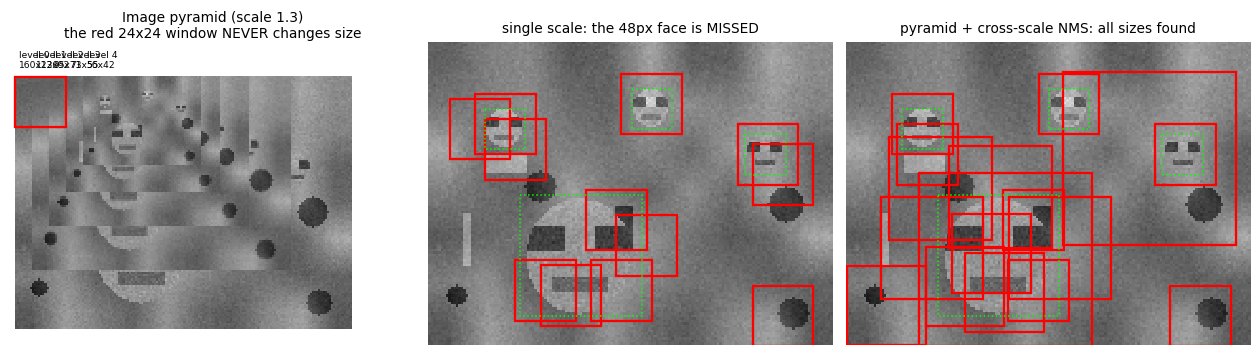

In [35]:
fig = plt.figure(figsize=(11.5, 3.6))
ax = fig.add_subplot(1, 3, 1)
for k, lvl in enumerate(PYR):
    ax.imshow(lvl, extent=[k * 8, k * 8 + lvl.shape[1], lvl.shape[0], 0], vmin=0, vmax=1)
    ax.text(k * 8 + 2, -4, 'level %d\n%dx%d' % (k, lvl.shape[1], lvl.shape[0]), fontsize=6)
ax.add_patch(mpatches.Rectangle((0, 0), 24, 24, fill=False, ec='red', lw=1.5))
ax.set_xlim(-2, 190); ax.set_ylim(125, -14); ax.axis('off')
ax.set_title('Image pyramid (scale 1.3)\nthe red 24x24 window NEVER changes size')

ax = fig.add_subplot(1, 3, 2)
ax.imshow(CANVAS, vmin=0, vmax=1)
for b in VJ_BOXES[nms(VJ_BOXES, VJ_SCORES, 0.5)]:
    ax.add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec='red', lw=1.5))
for b in CANVAS_BOXES:
    ax.add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec='lime', lw=1, ls=':'))
ax.set_title('single scale: the 48px face is MISSED'); ax.axis('off')

ax = fig.add_subplot(1, 3, 3)
ax.imshow(CANVAS, vmin=0, vmax=1)
for b in all_boxes[keep_pyr]:
    ax.add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec='red', lw=1.5))
for b in CANVAS_BOXES:
    ax.add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec='lime', lw=1, ls=':'))
ax.set_title('pyramid + cross-scale NMS: all sizes found'); ax.axis('off')
plt.tight_layout(); plt.show()

### 10.1 Interactive: the cost of scale invariance

The scale factor $s$ is a **density vs cost** dial:

* $s$ close to 1 gives a dense pyramid: better scale coverage, more levels, more compute. Real HOG
  detectors use $s \approx 1.05$ and pay for perhaps 30 levels.
* Large $s$ gives a cheap pyramid that **falls between scales**: an object halfway between two
  levels matches the window at neither, and the detection is missed or badly localised.
* Total windows converge to a geometric series, so **doubling the levels does not double the cost**:
  the top of the pyramid is nearly free. The bottom level dominates.

In [36]:
def pyramid_explorer(scale=1.30, n_levels=5, win=24, stride=2):
    H, W = CANVAS.shape
    sizes, wins = [], []
    for k in range(n_levels):
        h, w = int(round(H / scale ** k)), int(round(W / scale ** k))
        if min(h, w) < win:
            break
        sizes.append((h, w))
        wins.append(((h - win) // stride + 1) * ((w - win) // stride + 1))

    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.2))
    ax = axes[0]
    for k, (h, w) in enumerate(sizes):
        ax.add_patch(mpatches.Rectangle((k * 9, 0), w, h, fc='tab:blue', alpha=0.25, ec='tab:blue'))
        ax.text(k * 9 + 2, -3, '%dx%d' % (w, h), fontsize=6)
    ax.add_patch(mpatches.Rectangle((0, 0), win, win, fill=False, ec='red', lw=1.5))
    ax.set_xlim(-3, 200); ax.set_ylim(130, -12); ax.axis('off')
    ax.set_title('%d usable levels at scale %.2f\ndetectable object sizes: %d to %dpx'
                 % (len(sizes), scale, win, int(win * scale ** (len(sizes) - 1))))
    ax = axes[1]
    ax.bar(range(len(wins)), wins, color='tab:blue')
    ax.set_xlabel('pyramid level'); ax.set_ylabel('windows scanned')
    ax.set_title('total %d windows (%.2fx a single scan)' % (sum(wins), sum(wins) / max(wins[0], 1)))
    plt.tight_layout(); plt.show()
    print('levels %d | windows %d | object size range %d to %dpx | scale gap between levels %.0f%%'
          % (len(sizes), sum(wins), win, int(win * scale ** (len(sizes) - 1)), 100 * (scale - 1)))


interact(pyramid_explorer,
         scale=FloatSlider(value=1.30, min=1.05, max=2.0, step=0.05, description='scale $s$'),
         n_levels=IntSlider(value=5, min=1, max=12, step=1, description='levels'),
         win=IntSlider(value=24, min=12, max=48, step=4, description='window'),
         stride=IntSlider(value=2, min=1, max=8, step=1, description='stride'));

interactive(children=(FloatSlider(value=1.3, description='scale $s$', max=2.0, min=1.05, step=0.05), IntSlider…

---
## 11. Histograms of Oriented Gradients

> Dalal and Triggs, *Histograms of Oriented Gradients for Human Detection*, CVPR 2005.

Viola-Jones works beautifully for faces and poorly for pedestrians: a person has no reliable
bright/dark rectangle structure. HOG replaces "differences of boxes" with "**what directions do the
edges point, locally**". The pipeline, exactly as on the slide:

1. A **detection window slides over an image**.
2. At each location where the window is applied, **gradients are computed**.
3. The window is **evenly partitioned into cells**, and each pixel of the cell **contributes to the
   cell gradient orientation histogram**, weighted by its gradient magnitude.
4. Orientation histograms for **overlapping 2x2 blocks of cells are normalized** and collected to
   form the final descriptor. This is called **contrast normalization**.
5. The final descriptor goes to a **linear SVM**, which answers yes or no.

Why each step is there:

* **Gradients, not pixels**: gradients discard absolute brightness and keep shape.
* **Unsigned orientations in $[0, 180)$**: a dark person on a light background and a light person on
  a dark background produce gradients pointing in **opposite** directions, but the same edge
  orientation. Folding the angle makes the descriptor blind to that irrelevant flip.
* **Cells**: pooling into 8x8 cells buys **local translation tolerance**. A pixel may wander a few
  pixels and land in the same histogram.
* **Blocks with overlap**: normalising over a local block removes contrast and illumination gain.
  Blocks **overlap**, so each cell is normalised several times in different contexts and appears
  several times in the descriptor. It is redundant on purpose.

We build it bottom-up: gradients, then cells, then blocks, then the descriptor.

In [37]:
def image_gradients(img):
    """Dalal and Triggs deliberately use the simplest possible mask, [-1, 0, 1], with no smoothing.

    Returns gx, gy, magnitude, and UNSIGNED orientation in [0, 180).
    """
    gx, gy = np.zeros_like(img), np.zeros_like(img)
    gx[:, 1:-1] = img[:, 2:] - img[:, :-2]                  # centred difference
    gy[1:-1, :] = img[2:, :] - img[:-2, :]
    gx[:, 0] = img[:, 1] - img[:, 0]; gx[:, -1] = img[:, -1] - img[:, -2]        # one-sided at the border
    gy[0, :] = img[1, :] - img[0, :]; gy[-1, :] = img[-1, :] - img[-2, :]
    mag = np.sqrt(gx ** 2 + gy ** 2)
    ang = np.rad2deg(np.arctan2(gy, gx)) % 180.0            # fold to unsigned: 190 deg == 10 deg
    return gx, gy, mag, ang


def cell_histograms(mag, ang, cell=8, nbins=9):
    """Step 3: one orientation histogram per cell.

    Each pixel votes with its MAGNITUDE, split between the two nearest orientation bins in
    proportion to how close it is to each (bilinear voting), which stops the descriptor from
    jumping when an angle crosses a bin edge.
    """
    H, W = mag.shape
    cy, cx = H // cell, W // cell
    bin_w = 180.0 / nbins
    pos = ang / bin_w - 0.5                                  # bin centres sit at 0.5, 1.5, ...
    b0 = np.floor(pos).astype(int)
    frac = pos - b0
    b1 = (b0 + 1) % nbins
    b0 = b0 % nbins
    w0, w1 = (1 - frac) * mag, frac * mag                    # split the vote between b0 and b1
    hist = np.zeros((cy, cx, nbins))
    for i in range(cy):
        for j in range(cx):
            sl = (slice(i * cell, (i + 1) * cell), slice(j * cell, (j + 1) * cell))
            hist[i, j] = (np.bincount(b0[sl].ravel(), w0[sl].ravel(), nbins)
                          + np.bincount(b1[sl].ravel(), w1[sl].ravel(), nbins))
    return hist


def block_normalize(hist, block=2, eps=1e-6):
    """Step 4: contrast normalisation over OVERLAPPING blocks of cells (stride = 1 cell)."""
    cy, cx, nb = hist.shape
    by, bx = cy - block + 1, cx - block + 1
    out = np.zeros((by, bx, block * block * nb))
    for i in range(by):
        for j in range(bx):
            v = hist[i:i + block, j:j + block, :].ravel()
            out[i, j] = v / np.sqrt((v ** 2).sum() + eps ** 2)      # L2 normalisation
    return out


def hog_descriptor(img, cell=8, nbins=9, block=2):
    _, _, mag, ang = image_gradients(img)
    hist = cell_histograms(mag, ang, cell, nbins)
    return block_normalize(hist, block).ravel(), hist


# The classic Dalal-Triggs arithmetic: a 64x128 window must give 3780 numbers.
d, _ = hog_descriptor(np.random.default_rng(0).random((128, 64)))
cy, cx = 128 // 8, 64 // 8
print('window 64x128, cell 8x8, block 2x2, 9 bins')
print('  cells        : %d x %d' % (cy, cx))
print('  blocks       : %d x %d  (overlapping, so cells-1 in each direction)' % (cy - 1, cx - 1))
print('  per block    : 2 x 2 cells x 9 bins = %d numbers' % (2 * 2 * 9))
print('  descriptor   : %d x %d x %d = %d' % (cy - 1, cx - 1, 36, (cy - 1) * (cx - 1) * 36))
print('  our code says: %d' % len(d))
assert len(d) == 3780
print('\n3780 is exactly the number in the Dalal-Triggs paper.')

window 64x128, cell 8x8, block 2x2, 9 bins
  cells        : 16 x 8
  blocks       : 15 x 7  (overlapping, so cells-1 in each direction)
  per block    : 2 x 2 cells x 9 bins = 36 numbers
  descriptor   : 15 x 7 x 36 = 3780
  our code says: 3780

3780 is exactly the number in the Dalal-Triggs paper.


### 11.1 Gradients, and why orientation is the signal

The quiver plot shows the raw gradient field; the rose plot is the histogram of orientations over
the whole window, weighted by magnitude.

* Gradients are large **only at edges**, so the descriptor spends its budget on the silhouette and
  ignores flat regions automatically.
* The rose plot for a standing person has two lobes near **vertical edges** (the sides of the torso
  and legs are vertical, and their gradients point horizontally). Read the rose plot as
  "which edge orientations does this window contain, and how strongly".

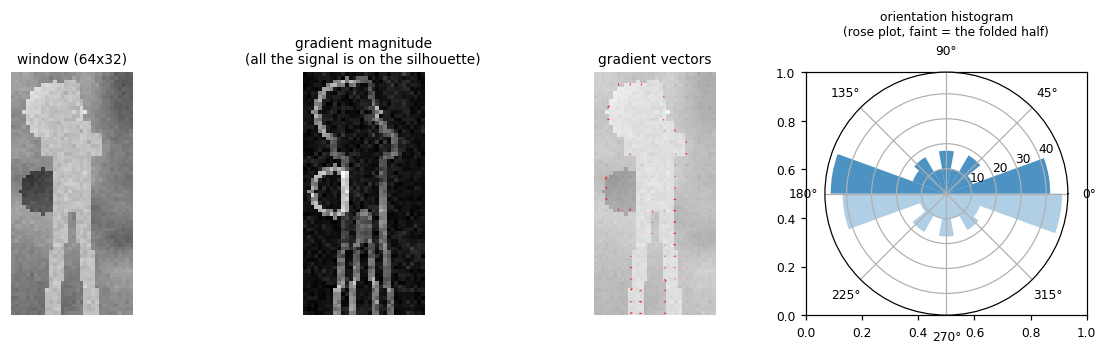

Unsigned orientation: the gradient at angle 30 and at 210 land in the SAME bin, so contrast reversal does not change the descriptor.


In [38]:
def make_person(rng, H=64, W=32, clutter=True):
    """A crude upright silhouette: head, torso, two legs, two arms, with pose jitter.

    The polarity is random (dark person on light background or the reverse), which is exactly
    the nuisance that HOG's UNSIGNED orientations are designed to ignore.
    """
    img = (0.35 + 0.3 * smooth_noise(H, W, rng, k=8)) if clutter else np.full((H, W), 0.5)
    if clutter:
        img = add_distractors(img, rng, 2)
    g = (np.arange(H) + 0.5) / H
    gx_ = (np.arange(W) + 0.5) / W
    yy, xx = np.meshgrid(g, gx_, indexing='ij')
    lean = rng.uniform(-0.05, 0.05)
    body = (((xx - 0.5 - lean * (0.5 - yy)) / 0.09) ** 2 + ((yy - 0.12) / 0.09) ** 2) <= 1   # head
    body |= (np.abs(xx - 0.5) < 0.17) & (yy > 0.20) & (yy < 0.58)                            # torso
    spread = rng.uniform(0.02, 0.09)
    body |= (np.abs(xx - (0.42 - spread * (yy - 0.58) * 3)) < 0.06) & (yy >= 0.58)           # left leg
    body |= (np.abs(xx - (0.58 + spread * (yy - 0.58) * 3)) < 0.06) & (yy >= 0.58)           # right leg
    body |= (np.abs(xx - 0.5) < 0.26) & (np.abs(yy - 0.30) < 0.05)                           # arms
    val = rng.uniform(0.05, 0.3) if rng.random() < 0.5 else rng.uniform(0.7, 0.95)
    img[body] = val + rng.normal(0, 0.02, img[body].shape)
    return np.clip(img + rng.normal(0, 0.02, img.shape), 0, 1)


person = make_person(np.random.default_rng(4))
gx, gy, mag, ang = image_gradients(person)

fig, axes = plt.subplots(1, 4, figsize=(11, 3.0))
axes[0].imshow(person, vmin=0, vmax=1); axes[0].set_title('window (64x32)'); axes[0].axis('off')
axes[1].imshow(mag); axes[1].set_title('gradient magnitude\n(all the signal is on the silhouette)')
axes[1].axis('off')
st = 3
yy, xx = np.mgrid[0:64:st, 0:32:st]
axes[2].imshow(person, vmin=0, vmax=1, alpha=0.5)
axes[2].quiver(xx, yy, gx[::st, ::st], gy[::st, ::st], color='r', scale=12, width=0.005)
axes[2].set_title('gradient vectors'); axes[2].axis('off')
ax = plt.subplot(1, 4, 4, projection='polar')
nb = 9
h = np.bincount((ang / (180 / nb)).astype(int).ravel() % nb, mag.ravel(), nb)
th = np.deg2rad((np.arange(nb) + 0.5) * (180 / nb))
ax.bar(th, h, width=np.deg2rad(180 / nb), color='tab:blue', alpha=0.8)
ax.bar(th + np.pi, h, width=np.deg2rad(180 / nb), color='tab:blue', alpha=0.35)
ax.set_thetamin(0); ax.set_thetamax(360)
ax.set_title('orientation histogram\n(rose plot, faint = the folded half)', fontsize=8)
plt.tight_layout(); plt.show()
print('Unsigned orientation: the gradient at angle %.0f and at %.0f land in the SAME bin,'
      % (30, 210), 'so contrast reversal does not change the descriptor.')

### 11.2 The descriptor, visualised

The classic HOG picture. In each cell we draw one line per orientation bin, with **length
proportional to that bin's weight**, drawn along the **edge direction** (perpendicular to the
gradient). That is why the visualisation of a person **traces the silhouette**.

Compare the two rows: the descriptor keeps the shape and throws away everything else.

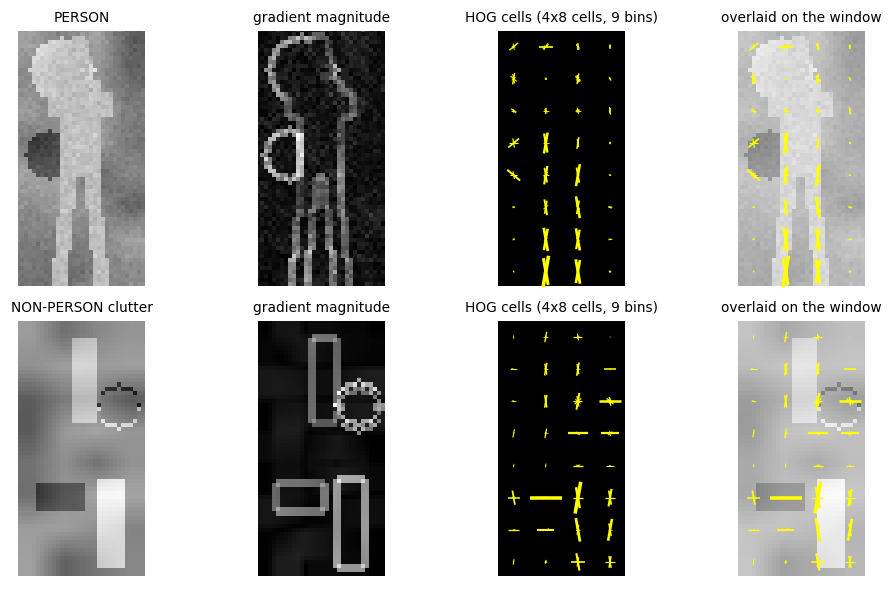

The person row traces a silhouette. The clutter row is noise pointing everywhere.
A linear SVM can separate those two patterns, which is section 11.4.


In [39]:
from matplotlib.collections import LineCollection


def plot_hog(hist, cell, ax, color='yellow', lw=0.8):
    """The classic HOG star chart: one segment per orientation bin per cell."""
    cy, cx, nb = hist.shape
    ang = (np.arange(nb) + 0.5) * (180.0 / nb)              # bin centre = GRADIENT orientation
    edge = np.deg2rad(ang + 90.0)                           # draw the EDGE, perpendicular to it
    mx = hist.max() + 1e-9
    segs, ws = [], []
    for i in range(cy):
        for j in range(cx):
            y0, x0 = (i + 0.5) * cell, (j + 0.5) * cell
            for b in range(nb):
                L = 0.5 * cell * hist[i, j, b] / mx
                dx, dy = L * np.cos(edge[b]), L * np.sin(edge[b])
                segs.append([(x0 - dx, y0 - dy), (x0 + dx, y0 + dy)]); ws.append(hist[i, j, b] / mx)
    ax.add_collection(LineCollection(segs, colors=color, linewidths=lw * np.array(ws) + 0.15))


neg_example = add_distractors(0.35 + 0.3 * smooth_noise(64, 32, np.random.default_rng(9), 8),
                              np.random.default_rng(9), 5)
neg_example = np.clip(neg_example, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(9.5, 5.4))
for row, (im, name) in enumerate([(person, 'PERSON'), (neg_example, 'NON-PERSON clutter')]):
    _, _, m, a = image_gradients(im)
    hist = cell_histograms(m, a, 8, 9)
    axes[row, 0].imshow(im, vmin=0, vmax=1); axes[row, 0].set_title('%s' % name)
    axes[row, 1].imshow(m); axes[row, 1].set_title('gradient magnitude')
    axes[row, 2].imshow(np.zeros_like(im)); plot_hog(hist, 8, axes[row, 2], lw=2.2)
    axes[row, 2].set_title('HOG cells (4x8 cells, 9 bins)')
    axes[row, 3].imshow(im, vmin=0, vmax=1, alpha=0.6); plot_hog(hist, 8, axes[row, 3], lw=2.2)
    axes[row, 3].set_title('overlaid on the window')
    for a_ in axes[row]:
        a_.set_xlim(0, 32); a_.set_ylim(64, 0); a_.axis('off')
plt.tight_layout(); plt.show()
print('The person row traces a silhouette. The clutter row is noise pointing everywhere.')
print('A linear SVM can separate those two patterns, which is section 11.4.')

### 11.3 Interactive: the HOG hyperparameters

The three numbers Dalal and Triggs tuned by grid search, and what each costs:

* **cell size**: small cells keep detail and blow up the descriptor; large cells are cheap and
  blurry. 8x8 was their sweet spot for 64x128 pedestrians.
* **orientation bins**: below about 9 bins the accuracy drops sharply; above it, little is gained.
* **block size**: the normalisation neighbourhood. Note how the descriptor length changes
  **non-linearly**, because overlapping blocks make each cell appear in several blocks.

Watch the **descriptor length** readout: it is $(c_y - b + 1)(c_x - b + 1) \cdot b^2 \cdot n_{bins}$.

In [40]:
def hog_explorer(cell=8, nbins=9, block=2):
    H, W = person.shape
    cy, cx = H // cell, W // cell
    if cy < block or cx < block:
        print('block does not fit in the cell grid'); return
    _, _, m, a = image_gradients(person)
    hist = cell_histograms(m, a, cell, nbins)
    desc = block_normalize(hist, block).ravel()
    by, bx = cy - block + 1, cx - block + 1

    fig, axes = plt.subplots(1, 3, figsize=(8.6, 3.4))
    axes[0].imshow(person, vmin=0, vmax=1)
    for i in range(cy + 1):
        axes[0].axhline(i * cell, color='cyan', lw=0.4)
    for j in range(cx + 1):
        axes[0].axvline(j * cell, color='cyan', lw=0.4)
    axes[0].add_patch(mpatches.Rectangle((0, 0), block * cell, block * cell, fill=False, ec='red', lw=2))
    axes[0].set_title('%dx%d cells of %dpx\n(red = one %dx%d block)' % (cy, cx, cell, block, block))
    axes[1].imshow(np.zeros_like(person)); plot_hog(hist, cell, axes[1], lw=2.2)
    axes[1].set_title('%d bins per cell' % nbins)
    axes[2].plot(desc, lw=0.5); axes[2].set_title('the descriptor: %d numbers' % len(desc))
    axes[2].set_xlabel('dimension'); axes[2].set_ylabel('value')
    for a_ in axes[:2]:
        a_.set_xlim(0, W); a_.set_ylim(H, 0); a_.axis('off')
    plt.tight_layout(); plt.show()
    print('descriptor length = (%d-%d+1)*(%d-%d+1) * %d^2 * %d = %d'
          % (cy, block, cx, block, block, nbins, len(desc)))
    print('the same window at 64x128 with these settings would give %d numbers'
          % ((128 // cell - block + 1) * (64 // cell - block + 1) * block * block * nbins))


interact(hog_explorer, cell=IntSlider(value=8, min=2, max=16, step=2, description='cell px'),
         nbins=IntSlider(value=9, min=2, max=18, step=1, description='bins'), block=IntSlider(value=2, min=1, max=4, step=1, description='block'));

interactive(children=(IntSlider(value=8, description='cell px', max=16, min=2, step=2), IntSlider(value=9, des…

### 11.4 HOG + linear SVM, and reading the weights

The last box on the slide is an **SVM**. It is linear, so the score is a dot product

$$score(I, p) = \mathbf{w} \cdot \phi(I, p)$$

and $\mathbf{w}$ lives in the **same space as the descriptor**. Each weight says "how much does this
orientation, in this cell, argue for a person". That makes the classifier **readable**, which is the
point of the "HOG: SVM weights" slide, and we reproduce its panels below:

* **Positive weights** should light up where a person's edges belong: the head and shoulders, the
  sides of the torso, and the legs.
* **Negative weights** mark the orientations that argue *against*, for instance strong edges where a
  person has empty background.

We train it with the hinge loss $\max(0, 1 - y \cdot s)$ plus $\ell_2$ regularisation, which **is** a
linear SVM, on a few hundred synthetic windows.

In [41]:
t0 = time.perf_counter()
svm_rng = np.random.default_rng(31)
Xp = [make_person(svm_rng) for _ in range(150)]
Xn = [np.clip(add_distractors(0.35 + 0.3 * smooth_noise(64, 32, svm_rng, 8), svm_rng, 5), 0, 1)
      for _ in range(150)]
HOG_X, HOG_HIST = [], []
for im in Xp + Xn:
    d, h = hog_descriptor(im)
    HOG_X.append(d); HOG_HIST.append(h)
HOG_X = np.array(HOG_X)
HOG_y = np.array([1.0] * 150 + [-1.0] * 150)                 # +/-1 labels for the hinge loss
print('HOG features: %s (%d dims per window) in %.2fs' % (HOG_X.shape, HOG_X.shape[1],
                                                          time.perf_counter() - t0))

Xt = torch.tensor(HOG_X, dtype=torch.float32)
yt = torch.tensor(HOG_y, dtype=torch.float32)
w = torch.zeros(Xt.shape[1], requires_grad=True)
b = torch.zeros(1, requires_grad=True)
opt = torch.optim.Adam([w, b], lr=0.05)
for step in range(300):
    opt.zero_grad()
    loss = torch.clamp(1 - yt * (Xt @ w + b), min=0).mean() + 1e-3 * (w ** 2).sum()
    loss.backward(); opt.step()
    if (step + 1) % 100 == 0:
        acc = (torch.sign(Xt @ w + b) == yt).float().mean().item()
        print('  step %3d | hinge loss %.4f | train accuracy %.3f' % (step + 1, loss.item(), acc))
W = w.detach().numpy()
print('linear SVM trained. accuracy %.3f on %d windows' % ((np.sign(HOG_X @ W + b.item()) == HOG_y).mean(),
                                                           len(HOG_y)))

HOG features: (300, 756) (756 dims per window) in 0.08s


  step 100 | hinge loss 0.0093 | train accuracy 1.000
  step 200 | hinge loss 0.0040 | train accuracy 1.000
  step 300 | hinge loss 0.0145 | train accuracy 1.000
linear SVM trained. accuracy 1.000 on 300 windows


/var/folders/j0/z7mrqrv9121_0pm8njw3pbxh0000gp/T/ipykernel_41880/4285831411.py:28: RuntimeWarning: divide by zero encountered in matmul
  print('linear SVM trained. accuracy %.3f on %d windows' % ((np.sign(HOG_X @ W + b.item()) == HOG_y).mean(),
/var/folders/j0/z7mrqrv9121_0pm8njw3pbxh0000gp/T/ipykernel_41880/4285831411.py:28: RuntimeWarning: overflow encountered in matmul
  print('linear SVM trained. accuracy %.3f on %d windows' % ((np.sign(HOG_X @ W + b.item()) == HOG_y).mean(),
/var/folders/j0/z7mrqrv9121_0pm8njw3pbxh0000gp/T/ipykernel_41880/4285831411.py:28: RuntimeWarning: invalid value encountered in matmul
  print('linear SVM trained. accuracy %.3f on %d windows' % ((np.sign(HOG_X @ W + b.item()) == HOG_y).mean(),


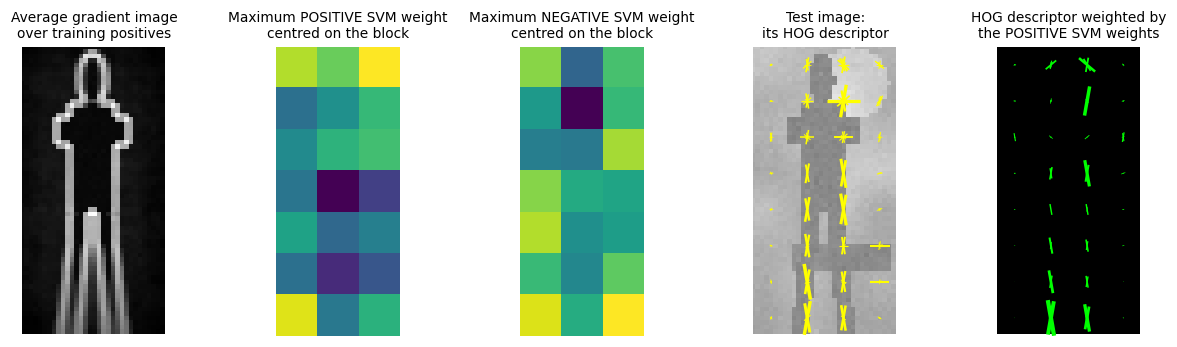

mean SVM score: persons +3.16, clutter -4.22  (the decision boundary is 0)
The green panel keeps the edges the SVM likes: head, shoulders, torso sides, legs.
This is the whole pre-deep-learning recipe: fixed features + a linear model + a pyramid.


In [42]:
def weights_to_cells(W, cy=8, cx=4, nbins=9, block=2):
    """Map block-space SVM weights back onto the cell grid, so we can draw them like a descriptor."""
    by, bx = cy - block + 1, cx - block + 1
    Wb = W.reshape(by, bx, block, block, nbins)
    out, cnt = np.zeros((cy, cx, nbins)), np.zeros((cy, cx, 1))
    for i in range(by):
        for j in range(bx):
            out[i:i + block, j:j + block] += Wb[i, j]
            cnt[i:i + block, j:j + block] += 1
    return out / cnt


avg_grad = np.mean([image_gradients(im)[2] for im in Xp], 0)
Wc = weights_to_cells(W)
test_im = make_person(np.random.default_rng(77))
_, _, m_t, a_t = image_gradients(test_im)
hist_t = cell_histograms(m_t, a_t, 8, 9)

fig, axes = plt.subplots(1, 5, figsize=(11.5, 3.2))
axes[0].imshow(avg_grad); axes[0].set_title('Average gradient image\nover training positives')
pos_blocks = W.reshape(7, 3, -1).max(-1)
axes[1].imshow(pos_blocks, cmap='viridis'); axes[1].set_title('Maximum POSITIVE SVM weight\ncentred on the block')
neg_blocks = (-W.reshape(7, 3, -1)).max(-1)
axes[2].imshow(neg_blocks, cmap='viridis'); axes[2].set_title('Maximum NEGATIVE SVM weight\ncentred on the block')
axes[3].imshow(test_im, vmin=0, vmax=1, alpha=0.55); plot_hog(hist_t, 8, axes[3], lw=2.2)
axes[3].set_title('Test image:\nits HOG descriptor')
axes[4].imshow(np.zeros_like(test_im))
plot_hog(hist_t * np.clip(Wc, 0, None), 8, axes[4], color='lime', lw=2.6)
axes[4].set_title('HOG descriptor weighted by\nthe POSITIVE SVM weights')
for a_ in [axes[0], axes[3], axes[4]]:
    a_.set_xlim(0, 32); a_.set_ylim(64, 0)
for a_ in axes:
    a_.axis('off')
plt.tight_layout(); plt.show()

score_pos = float(np.mean([hog_descriptor(im)[0] @ W + b.item() for im in Xp[:20]]))
score_neg = float(np.mean([hog_descriptor(im)[0] @ W + b.item() for im in Xn[:20]]))
print('mean SVM score: persons %+.2f, clutter %+.2f  (the decision boundary is 0)' % (score_pos, score_neg))
print('The green panel keeps the edges the SVM likes: head, shoulders, torso sides, legs.')
print('This is the whole pre-deep-learning recipe: fixed features + a linear model + a pyramid.')

---
## 12. Object detection using CNNs

Replace the hand-designed features with a learned CNN, and the recipe on the slide is:

* **Training step**: collect crops that do and do not contain the object, and train a CNN to answer
  **object / no object**. This is plain classification.
* **Testing step**: take **sliding windows of multiple scales** over the test image, run the CNN on
  each, and keep the windows that say yes.
* Then **NMS using class scores** cleans up the duplicates, exactly as in section 9.

Note what did **not** change: the sliding window, the pyramid, and NMS are all still here. The CNN
only replaced the *feature + classifier* box in the middle. That is the honest summary of detection
in 2013.

Our network is deliberately tiny, and its shape is chosen with the next two sections in mind:

| layer | output on a 24x24 window | note |
|-------|--------------------------|------|
| `conv1` 5x5, 8 filters | 20x20x8 | |
| `maxpool` 2x2 | 10x10x8 | stride 2 |
| `conv2` 5x5, 16 filters | 6x6x16 | |
| `maxpool` 2x2 | 3x3x16 | stride 2, total stride now **4** |
| `flatten` + `fc1` | 32 | 3x3x16 = 144 inputs |
| `fc_cls` / `fc_box` | 1 / 4 | the two heads of section 14 |

Two numbers to remember, because section 15 turns on them: the **receptive field is exactly 24**
and the **total stride is exactly 4**.

In [43]:
def prep(x):
    """Input normalisation. It is elementwise, so it commutes with cropping: a crop of the
    normalised image is the normalised crop. That matters for the equivalence test later."""
    return (x - 0.5) / 0.25


class TinyDetectorNet(nn.Module):
    """Trunk -> FC network -> two heads, the structure drawn on the box regression slide."""

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 5)              # 24 -> 20
        self.conv2 = nn.Conv2d(8, 16, 5)             # 10 -> 6
        self.fc1 = nn.Linear(16 * 3 * 3, 32)         # 3x3x16 = 144 -> 32
        self.fc_cls = nn.Linear(32, 1)               # face / not face
        self.fc_box = nn.Linear(32, 4)               # cx, cy, w, h in window-normalised coords

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)   # 20 -> 10
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)   # 6  -> 3
        x = x.flatten(1)                             # (N, 144)  <- the layer OverFeat deletes
        x = F.relu(self.fc1(x))
        return self.fc_cls(x)[:, 0], torch.sigmoid(self.fc_box(x))


net = TinyDetectorNet().to(device)
print(net)
print('\nparameters: %d' % sum(p.numel() for p in net.parameters()))
z_cls, z_box = net(torch.zeros(2, 1, 24, 24, device=device))
print('output on a 24x24 window: class logit %s, box %s' % (tuple(z_cls.shape), tuple(z_box.shape)))

TinyDetectorNet(
  (conv1): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=144, out_features=32, bias=True)
  (fc_cls): Linear(in_features=32, out_features=1, bias=True)
  (fc_box): Linear(in_features=32, out_features=4, bias=True)
)

parameters: 8229
output on a 24x24 window: class logit (2,), box (2, 4)


### 12.1 Training the CNN

The same patches Viola-Jones trained on, so the comparison is fair. Two losses on one trunk, which
is the picture on the localization slide:

* **Classification**: binary cross entropy on the class logit.
* **Bounding box regression**: **L2 loss** on $(x, y, w, h)$, exactly as the slide specifies.
* The box loss is applied **only to positive windows**. A background window has no box to regress
  towards, and asking the network to predict one would be meaningless supervision. Every detector
  from R-CNN onwards does exactly this masking.

In [44]:
Xc = prep(torch.tensor(Xtr[:, None], dtype=torch.float32))
yc = torch.tensor(ytr, dtype=torch.float32)
Bc = torch.tensor(Btr, dtype=torch.float32)
Xc_te = prep(torch.tensor(Xte[:, None], dtype=torch.float32))
yc_te = torch.tensor(yte, dtype=torch.float32)

torch.manual_seed(SEED)
net = TinyDetectorNet().to(device)
opt = torch.optim.Adam(net.parameters(), lr=2e-3)
gen = torch.Generator().manual_seed(SEED)
pos_weight = torch.tensor([(ytr == 0).sum() / (ytr == 1).sum()], device=device)

t0 = time.perf_counter()
for step in range(400):
    idx = torch.randint(0, len(Xc), (64,), generator=gen)
    xb, yb, bb = Xc[idx].to(device), yc[idx].to(device), Bc[idx].to(device)
    logit, box = net(xb)
    loss_cls = F.binary_cross_entropy_with_logits(logit, yb, pos_weight=pos_weight)
    per_sample = F.mse_loss(box, bb, reduction='none').sum(1)          # L2 loss on (x, y, w, h)
    loss_box = (per_sample * yb).sum() / yb.sum().clamp(min=1)         # positives only
    loss = loss_cls + 5.0 * loss_box
    opt.zero_grad(); loss.backward(); opt.step()
    if (step + 1) % 100 == 0:
        net.eval()
        with torch.no_grad():
            lg, _ = net(Xc_te.to(device))
            acc = ((lg > 0).float().cpu() == yc_te).float().mean().item()
        net.train()
        print('  step %3d | cls %.4f | box %.4f | held-out accuracy %.3f'
              % (step + 1, loss_cls.item(), loss_box.item(), acc))
net.eval()
print('trained in %.1fs on %s' % (time.perf_counter() - t0, device))

with torch.no_grad():
    lg_tr, _ = net(Xc.to(device))
    lg_tr = lg_tr.cpu().numpy()
SCORE_THR = float(np.quantile(lg_tr[ytr == 1], 0.02))       # keep 98% of the training faces
print('detection threshold (keeps 98%% of training faces): logit >= %.2f' % SCORE_THR)
print('at that threshold, %.2f%% of the training non-faces would fire'
      % (100 * (lg_tr[ytr == 0] >= SCORE_THR).mean()))

  step 100 | cls 0.0104 | box 0.0042 | held-out accuracy 0.996


  step 200 | cls 0.0023 | box 0.0023 | held-out accuracy 0.998


  step 300 | cls 0.0007 | box 0.0012 | held-out accuracy 1.000


  step 400 | cls 0.0032 | box 0.0011 | held-out accuracy 0.998
trained in 2.8s on cpu
detection threshold (keeps 98% of training faces): logit >= 3.15
at that threshold, 0.00% of the training non-faces would fire


### 12.2 The sliding window scan

The **naive** implementation, and we mean that literally: cut out every window and run the network
on each. We scan at **stride 4** because that is this network's total stride, which will let
section 15 compare against it exactly.

The heatmap is the class score at every window position. This is the same picture as the Viola-Jones
funnel, except every window has paid full price.

sliding window: 875 windows (25x35 grid) in 0.009s
windows above threshold: 7  ->  after NMS: 3


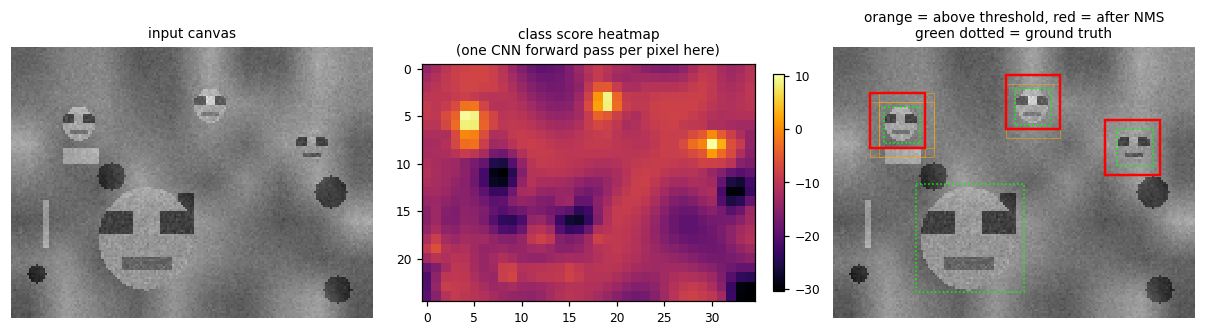

IoU of the CNN detections with each ground truth face: [0.444 0.444 0.444 0.   ]
faces found at IoU > 0.3: 3/4   at IoU > 0.5: 0/4   <- look at that second number


In [45]:
def sliding_window_scan(net, img, win=24, stride=4, batch=1024):
    """The expensive way: crop every window, run the network on all of them."""
    H, W = img.shape
    ys = np.arange(0, H - win + 1, stride)
    xs = np.arange(0, W - win + 1, stride)
    crops = np.stack([img[y:y + win, x:x + win] for y in ys for x in xs])
    t = prep(torch.tensor(crops[:, None], dtype=torch.float32))
    L, B = [], []
    with torch.no_grad():
        for i in range(0, len(t), batch):
            l, b = net(t[i:i + batch].to(device))
            L.append(l.cpu()); B.append(b.cpu())
    L = torch.cat(L).reshape(len(ys), len(xs)).numpy()
    B = torch.cat(B).reshape(len(ys), len(xs), 4).numpy()
    return L, B, xs, ys


t0 = time.perf_counter()
HEAT, BOXMAP, GX, GY = sliding_window_scan(net, CANVAS, stride=4)
t_slide = time.perf_counter() - t0
print('sliding window: %d windows (%dx%d grid) in %.3fs' % (HEAT.size, *HEAT.shape, t_slide))

yy, xx = np.where(HEAT >= SCORE_THR)
cnn_boxes = np.stack([GX[xx], GY[yy], GX[xx] + 24, GY[yy] + 24], 1).astype(float)
cnn_scores = HEAT[yy, xx]
keep_cnn = nms(cnn_boxes, cnn_scores, 0.3)
print('windows above threshold: %d  ->  after NMS: %d' % (len(cnn_boxes), len(keep_cnn)))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.0))
axes[0].imshow(CANVAS, vmin=0, vmax=1); axes[0].set_title('input canvas')
im = axes[1].imshow(HEAT, cmap='inferno')
axes[1].set_title('class score heatmap\n(one CNN forward pass per pixel here)')
plt.colorbar(im, ax=axes[1], fraction=0.03)
axes[2].imshow(CANVAS, vmin=0, vmax=1)
for b in cnn_boxes:
    axes[2].add_patch(mpatches.Rectangle((b[0], b[1]), 24, 24, fill=False, ec='orange', lw=0.6, alpha=0.6))
for b in cnn_boxes[keep_cnn]:
    axes[2].add_patch(mpatches.Rectangle((b[0], b[1]), 24, 24, fill=False, ec='red', lw=1.6))
for b in CANVAS_BOXES:
    axes[2].add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False,
                                         ec='lime', lw=1.0, ls=':'))
axes[2].set_title('orange = above threshold, red = after NMS\ngreen dotted = ground truth')
for a in [axes[0], axes[2]]:
    a.axis('off')
plt.tight_layout(); plt.show()

ious_cnn = best_iou_to_gt(cnn_boxes[keep_cnn], CANVAS_BOXES)
print('IoU of the CNN detections with each ground truth face: %s' % np.round(ious_cnn, 3))
print('faces found at IoU > 0.3: %d/%d   at IoU > 0.5: %d/%d   <- look at that second number'
      % ((ious_cnn > 0.3).sum(), len(ious_cnn), (ious_cnn > 0.5).sum(), len(ious_cnn)))

---
## 13. Sliding windows: the two disadvantages

The slide lists exactly two, and we have just measured both.

**1. Bounding boxes may not be tightly around the object.**

* Our detections are **24x24 windows**, but the faces are **16x16**. Even a perfectly centred window
  has $IoU = 16^2/24^2 = 0.44$, which **fails the standard 0.5 criterion**.
* The detector genuinely found every face and still scores zero by the book. The window grid can
  only produce boxes that are on the grid, at the size of the window: it cannot express "the face is
  actually these 16 pixels".
* Finer strides and more window sizes narrow the gap, at a cost that multiplies. **Section 14 fixes
  this properly by regressing the box.**

**2. Evaluating a CNN on all sliding windows is computationally intensive and time consuming.**

* We paid for **875 windows** on a tiny 120x160 canvas, at a coarse stride of 4, with a network of
  5k parameters. Scale any of those up and the number becomes frightening: at stride 1 the same
  canvas has 13,289 windows, and a real backbone costs a billion operations each.
* Adjacent windows overlap by **20 of their 24 pixels**, so we recomputed almost identical
  convolutions over and over. **Section 15 measures exactly how much was wasted.**

The slider below makes the trade concrete: stride down for better localization, and watch the
window count (and therefore the compute) grow quadratically.

In [46]:
def cost_explorer(win=24, stride=4, scales=1):
    H, W = CANVAS.shape
    total, rows = 0, []
    for k in range(scales):
        h, w = int(H / 1.3 ** k), int(W / 1.3 ** k)
        if min(h, w) < win:
            break
        n = ((h - win) // stride + 1) * ((w - win) // stride + 1)
        rows.append((k, h, w, n)); total += n
    flops_per_win = 200_000                                  # MACs for our tiny net on one window
    fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0))
    ax = axes[0]
    ax.imshow(CANVAS, vmin=0, vmax=1)
    grid = [(a, b) for a in range(0, H - win + 1, stride) for b in range(0, W - win + 1, stride)]
    for (y, x) in grid[::7]:                                 # draw every 7th, or the figure is black
        ax.add_patch(mpatches.Rectangle((x, y), win, win, fill=False, ec='red', lw=0.25, alpha=0.55))
    ax.add_patch(mpatches.Rectangle((0, 0), win, win, fill=False, ec='cyan', lw=2))
    ax.set_title('window %d, stride %d (every 7th drawn)' % (win, stride)); ax.axis('off')
    ax = axes[1]
    ax.bar([r[0] for r in rows], [r[3] for r in rows], color='tab:blue')
    ax.set_xlabel('pyramid level'); ax.set_ylabel('windows')
    ax.set_title('%d windows total = %.1f MFLOPs' % (total, total * flops_per_win * 2 / 1e6))
    plt.tight_layout(); plt.show()
    print('window %d, stride %d, %d scale(s) -> %d windows, about %.1f MFLOPs for our tiny net'
          % (win, stride, len(rows), total, total * flops_per_win * 2 / 1e6))
    print('overlap between neighbouring windows: %.0f%% of the pixels are shared'
          % (100 * (1 - stride / win) if stride < win else 0))
    print('for reference: AlexNet is ~700 MFLOPs PER WINDOW. Multiply that by %d.' % total)


interact(cost_explorer, win=IntSlider(value=24, min=8, max=64, step=4, description='window'),
         stride=IntSlider(value=4, min=1, max=16, step=1, description='stride'),
         scales=IntSlider(value=1, min=1, max=6, step=1, description='pyramid levels'));

interactive(children=(IntSlider(value=24, description='window', max=64, min=8, step=4), IntSlider(value=4, des…

---
## 14. Object localization using bounding box regression

The fix for disadvantage 1. Keep the trunk, and hang **two heads** off the same FC network:

* **Classification head**, trained with **cross-entropy loss**, giving the class scores.
* **Bounding-box regression head**, trained with **L2 loss**, giving **X, Y, H, W**.

* The box is parameterised **relative to the window**: the head outputs the centre and the size in
  window-normalised units, so it is predicting a **correction to the window**, not absolute image
  coordinates. A head that had to output absolute pixels would have to know where the window is.
* This is what turns detection from "which grid cells fired" into "where exactly is the object". The
  window only has to be **close enough** for the head to see the object and correct the rest.
* The regression head is trained **only on positives**, as in section 12.1.

> Note the slide specifies the **L2 loss** here. Fast R-CNN will later replace it with **smooth L1**
> because L2 lets a single badly-labelled box dominate the gradient. That is Lecture 2, and it is
> exercise 3 at the end of this notebook.

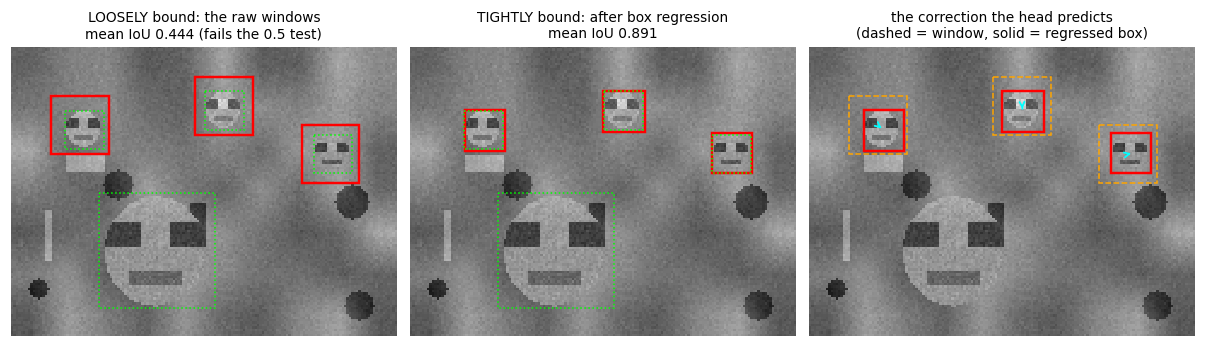

IoU per face, raw window     :     [0.444 0.444 0.444 0.   ]
IoU per face, after regression:    [0.884 0.863 0.926 0.   ]

faces passing the standard IoU > 0.5 criterion:
  raw sliding window : 0 / 4
  after box regression: 3 / 4

Same network, same forward pass, 4 extra numbers per window.


In [47]:
def decode_boxes(boxmap, xs, ys, win=24):
    """Turn the head's window-normalised (cx, cy, w, h) into absolute image boxes."""
    out = np.zeros(boxmap.shape[:2] + (4,))
    for i, y in enumerate(ys):
        for j, x in enumerate(xs):
            cx, cy, bw, bh = boxmap[i, j]
            cx, cy, bw, bh = x + cx * win, y + cy * win, bw * win, bh * win
            out[i, j] = [cx - bw / 2, cy - bh / 2, cx + bw / 2, cy + bh / 2]
    return out


DEC = decode_boxes(BOXMAP, GX, GY)
reg_boxes = DEC[yy, xx]
keep_reg = nms(reg_boxes, cnn_scores, 0.3)

loose_iou = best_iou_to_gt(cnn_boxes[keep_cnn], CANVAS_BOXES)
tight_iou = best_iou_to_gt(reg_boxes[keep_reg], CANVAS_BOXES)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
axes[0].imshow(CANVAS, vmin=0, vmax=1)
for b in cnn_boxes[keep_cnn]:
    axes[0].add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec='red', lw=1.6))
for b in CANVAS_BOXES:
    axes[0].add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False,
                                         ec='lime', lw=1.0, ls=':'))
axes[0].set_title('LOOSELY bound: the raw windows\nmean IoU %.3f (fails the 0.5 test)' % loose_iou[:3].mean())

axes[1].imshow(CANVAS, vmin=0, vmax=1)
for b in reg_boxes[keep_reg]:
    axes[1].add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec='red', lw=1.6))
for b in CANVAS_BOXES:
    axes[1].add_patch(mpatches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False,
                                         ec='lime', lw=1.0, ls=':'))
axes[1].set_title('TIGHTLY bound: after box regression\nmean IoU %.3f' % tight_iou[:3].mean())

axes[2].imshow(CANVAS, vmin=0, vmax=1)
for b0, b1 in zip(cnn_boxes[keep_cnn], reg_boxes[keep_reg]):
    axes[2].add_patch(mpatches.Rectangle((b0[0], b0[1]), 24, 24, fill=False, ec='orange', lw=1.0, ls='--'))
    axes[2].add_patch(mpatches.Rectangle((b1[0], b1[1]), b1[2] - b1[0], b1[3] - b1[1],
                                         fill=False, ec='red', lw=1.6))
    axes[2].annotate('', xy=((b1[0] + b1[2]) / 2, (b1[1] + b1[3]) / 2),
                     xytext=((b0[0] + b0[2]) / 2, (b0[1] + b0[3]) / 2),
                     arrowprops=dict(arrowstyle='->', color='cyan', lw=1.2))
axes[2].set_title('the correction the head predicts\n(dashed = window, solid = regressed box)')
for a in axes:
    a.axis('off')
plt.tight_layout(); plt.show()

print('%-34s %s' % ('IoU per face, raw window     :', np.round(loose_iou, 3)))
print('%-34s %s' % ('IoU per face, after regression:', np.round(tight_iou, 3)))
print('\nfaces passing the standard IoU > 0.5 criterion:')
print('  raw sliding window : %d / %d' % ((loose_iou > 0.5).sum(), len(loose_iou)))
print('  after box regression: %d / %d' % ((tight_iou > 0.5).sum(), len(tight_iou)))
print('\nSame network, same forward pass, 4 extra numbers per window.')

---
## 15. OverFeat: the sliding window IS a convolution

> Sermanet et al, *OverFeat: Integrated Recognition, Localization and Detection using Convolutional
> Networks*, ICLR 2014. **Winner of the ILSVRC 2013 localization challenge.**

**Intuition** (from the slide): **avoid computation time over sub-windows by applying the filter
directly to the image.**

Look again at what the sliding window did. Two neighbouring 24x24 windows overlap in 20 columns of
pixels. Both windows ran `conv1` over that shared region, and got **identical numbers** both times.
A convolution over the whole image computes each of those responses **once**.

The blocker is the **fully connected layer**. It demands a fixed-size input, which is the only
reason we were cropping fixed-size windows in the first place. So OverFeat deletes it:

**The network is fully convolutional, replacing fully connected layers with convolutional layers. Why?**

Because an FC layer **already is** a convolution:

* An FC layer on a $3 \times 3 \times 256$ feature map, flattened to $1 \times 2304$, with 512
  outputs, does 512 dot products of length 2304.
* A $3 \times 3$ convolution with 512 filters on that same $3 \times 3 \times 256$ map does 512 dot
  products of length $3 \times 3 \times 256 = 2304$, giving $1 \times 1 \times 512$. **Same numbers.**
* The difference appears when the input **grows**. The FC layer breaks. The convolution simply slides
  and returns $2 \times 2 \times 512$ on a $4 \times 4 \times 256$ input: the FC layer applied at
  each of the four positions, **sharing every convolution below it**.

We prove all of this numerically, in three steps.

### 15.1 Step 1: an FC layer is a convolution (the slide's 3x3x256 example)

The surgery is a **reshape of the weight matrix**, and nothing else:

$$\underbrace{W_{fc}}_{512 \times 2304} \;\longrightarrow\; \underbrace{W_{conv}}_{512 \times 256 \times 3 \times 3}$$

**Why the plain reshape is correct, and the one place it can go wrong.** `flatten` on an
$(N, C, H, W)$ tensor lays memory out as `c * H * W + h * W + w` (channel major), and `Conv2d`
stores its weight as `(out, in, kh, kw)` and contracts in that same order. The two agree, so
`view` is a no-op reinterpretation. Had you flattened **channels last** (say `permute(0,2,3,1)`
first), this reshape would silently produce garbage: the numbers would be there, in the wrong
order. This is the single most common bug in the conversion.

In [48]:
torch.manual_seed(0)
feat = torch.randn(1, 256, 3, 3)                     # a CNN trunk output for ONE sub-window
fc = nn.Linear(3 * 3 * 256, 512)                     # the slide's '1x2304 -> 512' FC layer
conv = nn.Conv2d(256, 512, 3)                        # '3x3 convolution, 512 filters'
with torch.no_grad():
    conv.weight.copy_(fc.weight.view(512, 256, 3, 3))     # THE surgery
    conv.bias.copy_(fc.bias)

with torch.no_grad():
    y_fc = fc(feat.flatten(1))                       # (1, 512)
    y_conv = conv(feat)                              # (1, 512, 1, 1)
print('FULLY CONNECTED : 3x3x256 -> flatten -> 1x2304 -> FC -> %s' % (tuple(y_fc.shape),))
print('FULLY CONVOLUTIONAL: 3x3x256 -> 3x3 conv, 512 filters -> %s' % (tuple(y_conv.shape),))
print('max |difference| = %.3e' % (y_fc - y_conv.flatten(1)).abs().max().item())
assert torch.allclose(y_fc, y_conv.flatten(1), atol=1e-5)

# Now grow the input, exactly as the slide's second row does: 4x4x256.
big_feat = torch.randn(1, 256, 4, 4)
with torch.no_grad():
    y_big = conv(big_feat)                           # (1, 512, 2, 2)
print('\ninput 4x4x256 -> 3x3 conv -> %s   (the slide says 2x2x512)' % (tuple(y_big.shape),))
worst = 0.0
for i in range(2):
    for j in range(2):
        with torch.no_grad():
            y_crop = fc(big_feat[:, :, i:i + 3, j:j + 3].flatten(1))[0]     # FC on this sub-window
        worst = max(worst, (y_crop - y_big[0, :, i, j]).abs().max().item())
print('max |FC(sub-window) - conv output cell| over the 4 positions = %.3e' % worst)
assert worst < 1e-4
print('\nThe conv output cell (i,j) IS the FC layer applied to sub-window (i,j). Same weights.')

FULLY CONNECTED : 3x3x256 -> flatten -> 1x2304 -> FC -> (1, 512)
FULLY CONVOLUTIONAL: 3x3x256 -> 3x3 conv, 512 filters -> (1, 512, 1, 1)
max |difference| = 0.000e+00

input 4x4x256 -> 3x3 conv -> (1, 512, 2, 2)   (the slide says 2x2x512)
max |FC(sub-window) - conv output cell| over the 4 positions = 3.457e-06

The conv output cell (i,j) IS the FC layer applied to sub-window (i,j). Same weights.


### 15.2 Step 2: the OverFeat figure, reproduced exactly

This is the figure on the slide: the same network fed a **14x14** input and a **16x16** input.

| input | 5x5 conv | 2x2 pool | 5x5 conv | 1x1 conv | 1x1 conv |
|-------|----------|----------|----------|----------|----------|
| **14x14** | 10x10 | 5x5 | **1x1** | 1x1 | **1x1 output** |
| **16x16** | 12x12 | 6x6 | **2x2** | 2x2 | **2x2 output** |

The network has receptive field **14** and total stride **2** (one 2x2 pool). So the 2x2 output on a
16x16 input must be the 14x14 classifier applied at offsets $\{0, 2\} \times \{0, 2\}$. We check
every cell against an actual crop.

We also check the **failure case**, which is where the real understanding is: a crop at offset **1**
is **not** a multiple of the total stride, so it lands between the pooling grid cells and matches
**nothing**. The equivalence is exact, but only on the stride lattice.

In [49]:
class OverFeatToy(nn.Module):
    """The slide's figure: 5x5 conv -> 2x2 pool -> 5x5 conv -> 1x1 conv -> 1x1 conv.
    Receptive field 14, total stride 2."""

    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(1, 4, 5); self.c2 = nn.Conv2d(4, 8, 5)
        self.c3 = nn.Conv2d(8, 8, 1); self.c4 = nn.Conv2d(8, 2, 1)

    def forward(self, x, trace=False):
        sizes = [('input', x.shape[-1])]
        x = F.relu(self.c1(x)); sizes.append(('5x5 conv', x.shape[-1]))
        x = F.max_pool2d(x, 2); sizes.append(('2x2 pool', x.shape[-1]))
        x = F.relu(self.c2(x)); sizes.append(('5x5 conv', x.shape[-1]))
        x = F.relu(self.c3(x)); sizes.append(('1x1 conv', x.shape[-1]))
        x = self.c4(x); sizes.append(('1x1 conv (output)', x.shape[-1]))
        return (x, sizes) if trace else x


toy = OverFeatToy().eval()
torch.manual_seed(1)
x16 = torch.randn(1, 1, 16, 16)

for S in (14, 16):
    with torch.no_grad():
        _, tr = toy(torch.zeros(1, 1, S, S), trace=True)
    print('%-8s %s' % ('%dx%d:' % (S, S), '  ->  '.join('%s %dx%d' % (n, s, s) for n, s in tr)))

with torch.no_grad():
    big = toy(x16)                                            # ONE pass over the 16x16 input
print('\n16x16 -> output grid %s: 4 classifier positions from ONE forward pass' % (tuple(big.shape),))

worst = 0.0
for i, oy in enumerate((0, 2)):                                # offsets must be multiples of stride 2
    for j, ox in enumerate((0, 2)):
        with torch.no_grad():
            crop = toy(x16[:, :, oy:oy + 14, ox:ox + 14])      # the sliding window, done by hand
        d = (crop[0, :, 0, 0] - big[0, :, i, j]).abs().max().item()
        worst = max(worst, d)
        print('  crop at offset (%d,%d) vs output cell (%d,%d): max|diff| = %.3e' % (oy, ox, i, j, d))
assert worst < 1e-5
print('EXACT. The 2x2 output map IS the four sliding windows.')

with torch.no_grad():
    bad = toy(x16[:, :, 1:15, 1:15])                           # offset 1: NOT on the stride lattice
mind = min((bad[0, :, 0, 0] - big[0, :, i, j]).abs().max().item() for i in range(2) for j in range(2))
print('\ncrop at offset (1,1), which is NOT a multiple of the stride 2:')
print('  closest output cell still differs by %.3e  <- as it must' % mind)
print('  the fully convolutional network can only emulate a sliding window ON its stride lattice.')
print('  (OverFeat recovers a finer effective stride by pooling at several offsets.)')

14x14:   input 14x14  ->  5x5 conv 10x10  ->  2x2 pool 5x5  ->  5x5 conv 1x1  ->  1x1 conv 1x1  ->  1x1 conv (output) 1x1
16x16:   input 16x16  ->  5x5 conv 12x12  ->  2x2 pool 6x6  ->  5x5 conv 2x2  ->  1x1 conv 2x2  ->  1x1 conv (output) 2x2

16x16 -> output grid (1, 2, 2, 2): 4 classifier positions from ONE forward pass
  crop at offset (0,0) vs output cell (0,0): max|diff| = 2.980e-08
  crop at offset (0,2) vs output cell (0,1): max|diff| = 4.470e-08
  crop at offset (2,0) vs output cell (1,0): max|diff| = 7.451e-09
  crop at offset (2,2) vs output cell (1,1): max|diff| = 3.725e-08
EXACT. The 2x2 output map IS the four sliding windows.

crop at offset (1,1), which is NOT a multiple of the stride 2:
  closest output cell still differs by 1.531e-02  <- as it must
  the fully convolutional network can only emulate a sliding window ON its stride lattice.
  (OverFeat recovers a finer effective stride by pooling at several offsets.)


### 15.3 Step 3: our detector, made fully convolutional

Now the real thing. We take the network trained in section 12, **change no weights**, and rebuild it
with the FC layers expressed as convolutions:

* `fc1` (144 -> 32) becomes a **3x3 conv** (16 in, 32 out): its input was a 3x3x16 map.
* `fc_cls` (32 -> 1) and `fc_box` (32 -> 4) become **1x1 convs**: their input was 1x1x32.

Feed the whole **120x160 canvas** through it once and the output is a **25x35 grid**, which is
exactly the 875 windows we scanned one at a time in section 12.2. The claim to test is strong, so
we test it strongly: **every one of the 875 class scores and every one of the 3500 box coordinates
must match the sliding window, numerically.**

In [50]:
class TinyDetectorFCN(nn.Module):
    """The SAME network with the FC layers rewritten as convolutions. No retraining, no fine tuning:
    the weights are copied, only their shape is reinterpreted."""

    def __init__(self, net):
        super().__init__()
        self.conv1, self.conv2 = net.conv1, net.conv2          # the trunk is already convolutional
        self.fc1_conv = nn.Conv2d(16, 32, 3)                   # fc1 saw a 3x3x16 map -> 3x3 conv
        self.cls_conv = nn.Conv2d(32, 1, 1)                    # fc_cls saw 1x1x32   -> 1x1 conv
        self.box_conv = nn.Conv2d(32, 4, 1)
        with torch.no_grad():
            self.fc1_conv.weight.copy_(net.fc1.weight.view(32, 16, 3, 3))
            self.fc1_conv.bias.copy_(net.fc1.bias)
            self.cls_conv.weight.copy_(net.fc_cls.weight.view(1, 32, 1, 1))
            self.cls_conv.bias.copy_(net.fc_cls.bias)
            self.box_conv.weight.copy_(net.fc_box.weight.view(4, 32, 1, 1))
            self.box_conv.bias.copy_(net.fc_box.bias)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = F.relu(self.fc1_conv(x))                           # <- no flatten, so no fixed size
        return self.cls_conv(x)[:, 0], torch.sigmoid(self.box_conv(x))


fcn = TinyDetectorFCN(net).to(device).eval()


def fcn_scan(fcn, img):
    """The whole image, ONE forward pass."""
    t = prep(torch.tensor(img[None, None], dtype=torch.float32)).to(device)
    with torch.no_grad():
        l, b = fcn(t)
    return l[0].cpu().numpy(), b[0].permute(1, 2, 0).cpu().numpy()


t0 = time.perf_counter()
HEAT_FCN, BOXMAP_FCN = fcn_scan(fcn, CANVAS)
t_fcn = time.perf_counter() - t0

print('sliding window : %d separate 24x24 crops -> heatmap %s' % (HEAT.size, HEAT.shape))
print('fully conv     : ONE pass over the %dx%d canvas -> heatmap %s'
      % (CANVAS.shape[1], CANVAS.shape[0], HEAT_FCN.shape))
assert HEAT.shape == HEAT_FCN.shape, 'output grids must line up'

d_cls = np.abs(HEAT - HEAT_FCN).max()
d_box = np.abs(BOXMAP - BOXMAP_FCN).max()
print('\n--- THE TEST -------------------------------------------------')
print('max |class score difference| over all %d windows : %.3e' % (HEAT.size, d_cls))
print('max |box coord difference|   over all %d numbers : %.3e' % (BOXMAP.size, d_box))
print('class score range for scale: %.2f to %.2f' % (HEAT.min(), HEAT.max()))
assert d_cls < 1e-4, 'FC-to-conv equivalence broken for the class head'
assert d_box < 1e-4, 'FC-to-conv equivalence broken for the box head'
print('PASSED: the two are the same function. Differences are float32 rounding only.')
print('--------------------------------------------------------------')

sliding window : 875 separate 24x24 crops -> heatmap (25, 35)
fully conv     : ONE pass over the 160x120 canvas -> heatmap (25, 35)

--- THE TEST -------------------------------------------------
max |class score difference| over all 875 windows : 5.722e-06
max |box coord difference|   over all 3500 numbers : 2.980e-07
class score range for scale: -30.42 to 10.32
PASSED: the two are the same function. Differences are float32 rounding only.
--------------------------------------------------------------


### 15.4 What did we save?

Wall-clock time on a small CPU is noisy, so we also count **multiply-accumulates**, which is exact
and does not depend on the machine. The per-layer breakdown is the interesting part, and it explains
the OverFeat figure precisely:

* **The early layers save the most.** `conv1` runs at stride 1, and neighbouring windows overlap
  almost completely, so the sliding version recomputes each response about 19 times.
* **The saving shrinks with depth**, because deeper layers have larger strides and therefore less
  overlap between windows.
* **The classifier layers save nothing at all.** By then there is exactly one evaluation per window
  either way. The win is entirely in **sharing the trunk**, which is exactly the yellow shared region
  in the slide's figure.

layer                    sliding (MACs)       fully conv      ratio
--------------------------------------------------------------------
conv1 5x5 (1->8)             70,000,000        3,619,200      19.3x
conv2 5x5 (8->16)           100,800,000       12,787,200       7.9x
fc1 / 3x3 conv                4,032,000        4,032,000       1.0x
heads / 1x1 convs               140,000          140,000       1.0x
--------------------------------------------------------------------
TOTAL                       174,972,000       20,578,400       8.5x



wall clock (best of 3, cpu):
  sliding window (batched crops):     9.0 ms
  fully convolutional, one pass :     0.6 ms   -> 15.0x faster

Note the sliding number is already GENEROUS: we batched all 875 crops into one tensor.
The saving grows with the window/stride overlap ratio, and with network depth before the FC.


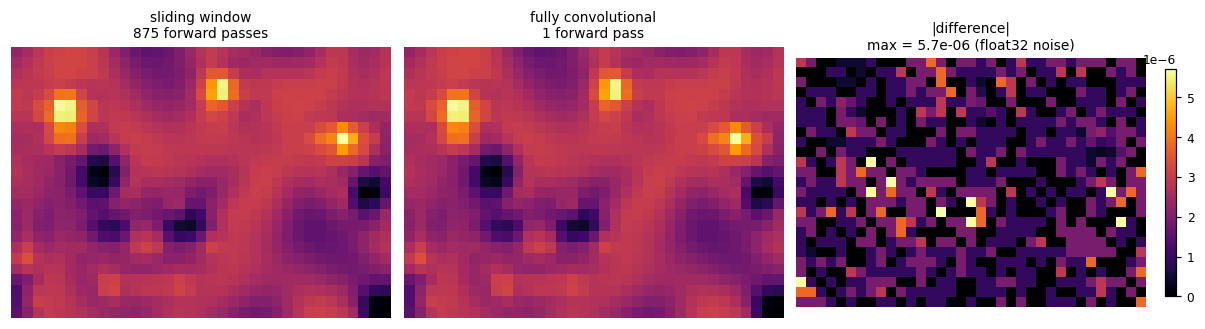

In [51]:
def macs_conv(cin, cout, k, oh, ow):
    return cin * cout * k * k * oh * ow


n_win = HEAT.size
rows = [
    ('conv1 5x5 (1->8)',   n_win * macs_conv(1, 8, 5, 20, 20),   macs_conv(1, 8, 5, 116, 156)),
    ('conv2 5x5 (8->16)',  n_win * macs_conv(8, 16, 5, 6, 6),    macs_conv(8, 16, 5, 54, 74)),
    ('fc1 / 3x3 conv',     n_win * macs_conv(16, 32, 3, 1, 1),   macs_conv(16, 32, 3, 25, 35)),
    ('heads / 1x1 convs',  n_win * macs_conv(32, 5, 1, 1, 1),    macs_conv(32, 5, 1, 25, 35)),
]
print('%-22s %16s %16s %10s' % ('layer', 'sliding (MACs)', 'fully conv', 'ratio'))
print('-' * 68)
for name, a, b in rows:
    print('%-22s %16s %16s %9.1fx' % (name, '{:,}'.format(a), '{:,}'.format(b), a / b))
ta, tb = sum(r[1] for r in rows), sum(r[2] for r in rows)
print('-' * 68)
print('%-22s %16s %16s %9.1fx' % ('TOTAL', '{:,}'.format(ta), '{:,}'.format(tb), ta / tb))

# Wall clock, best of 3 runs each.
ts = []
for _ in range(3):
    t0 = time.perf_counter(); sliding_window_scan(net, CANVAS, stride=4); ts.append(time.perf_counter() - t0)
tf = []
for _ in range(3):
    t0 = time.perf_counter(); fcn_scan(fcn, CANVAS); tf.append(time.perf_counter() - t0)
print('\nwall clock (best of 3, %s):' % device)
print('  sliding window (batched crops): %7.1f ms' % (min(ts) * 1e3))
print('  fully convolutional, one pass : %7.1f ms   -> %.1fx faster'
      % (min(tf) * 1e3, min(ts) / min(tf)))
print('\nNote the sliding number is already GENEROUS: we batched all %d crops into one tensor.' % n_win)
print('The saving grows with the window/stride overlap ratio, and with network depth before the FC.')

fig, axes = plt.subplots(1, 3, figsize=(11, 2.9))
axes[0].imshow(HEAT, cmap='inferno'); axes[0].set_title('sliding window\n%d forward passes' % n_win)
axes[1].imshow(HEAT_FCN, cmap='inferno'); axes[1].set_title('fully convolutional\n1 forward pass')
im = axes[2].imshow(np.abs(HEAT - HEAT_FCN), cmap='inferno')
axes[2].set_title('|difference|\nmax = %.1e (float32 noise)' % d_cls)
plt.colorbar(im, ax=axes[2], fraction=0.03)
for a in axes[:2]:
    a.axis('off')
axes[2].axis('off')
plt.tight_layout(); plt.show()

### 15.5 Interactive: input size to output grid

The relationship OverFeat exploits. For our detector (receptive field 24, total stride 4):

$$\text{output grid} = \left\lfloor \frac{S - \text{RF}}{\text{stride}} \right\rfloor + 1$$

* The network **has no input size**. Feed it anything at least as big as the receptive field and it
  returns a grid of classifier outputs, one per window position.
* Each extra `stride` pixels of input buys **one more window row/column**, for the cost of the top
  layers only.
* This is also how OverFeat does **multi-scale**: run the same fully convolutional network over each
  level of an image pyramid. Bigger input, bigger output grid, no retraining, nothing recomputed.

The widget **runs the real network** to fill in the "actual" column, so the formula is checked, not
just recited.

In [52]:
def overfeat_grid(input_h=120, input_w=160):
    chain = [('input', input_h, input_w)]
    h, w = input_h - 4, input_w - 4;      chain.append(('conv1 5x5', h, w))
    h, w = h // 2, w // 2;                chain.append(('pool 2x2', h, w))
    h, w = h - 4, w - 4;                  chain.append(('conv2 5x5', h, w))
    h, w = h // 2, w // 2;                chain.append(('pool 2x2', h, w))
    h, w = h - 2, w - 2;                  chain.append(('fc1 as 3x3 conv', h, w))
    chain.append(('heads as 1x1 conv', h, w))
    if min(h, w) < 1:
        print('input smaller than the 24x24 receptive field: no valid window'); return

    with torch.no_grad():                                     # check against the REAL network
        real = fcn(torch.zeros(1, 1, input_h, input_w, device=device))[0].shape[1:]
    pred = ((input_h - 24) // 4 + 1, (input_w - 24) // 4 + 1)

    fig, ax = plt.subplots(figsize=(9.5, 2.6))
    for k, (name, hh, ww) in enumerate(chain):
        ax.add_patch(mpatches.Rectangle((k * 3, -hh / 2 / 40), 2, hh / 40,
                                        fc='tab:blue', alpha=0.35, ec='tab:blue'))
        ax.text(k * 3 + 1, hh / 2 / 40 + 0.12, '%dx%d' % (ww, hh), ha='center', fontsize=7)
        ax.text(k * 3 + 1, -hh / 2 / 40 - 0.35, name, ha='center', fontsize=6.5, rotation=0)
        if k < len(chain) - 1:
            ax.annotate('', xy=(k * 3 + 2.9, 0), xytext=(k * 3 + 2.1, 0),
                        arrowprops=dict(arrowstyle='->', lw=1))
    ax.set_xlim(-1, len(chain) * 3); ax.set_ylim(-2.4, 2.4); ax.axis('off')
    ax.set_title('input %dx%d  ->  output grid %dx%d  =  %d sliding windows, one forward pass'
                 % (input_w, input_h, real[1], real[0], real[0] * real[1]))
    plt.tight_layout(); plt.show()
    print('formula floor((S - RF)/stride) + 1 with RF=24, stride=4 -> %dx%d' % pred)
    print('actual output of the network                            -> %dx%d' % (real[0], real[1]))
    print('windows: %d   |   equivalent sliding-window cost: %d separate forward passes'
          % (real[0] * real[1], real[0] * real[1]))


interact(overfeat_grid, input_h=IntSlider(value=120, min=24, max=240, step=4, description='input H'),
         input_w=IntSlider(value=160, min=24, max=320, step=4, description='input W'));

interactive(children=(IntSlider(value=120, description='input H', max=240, min=24, step=4), IntSlider(value=16…

### 15.6 The rest of OverFeat

We have built the engine. The full system adds two ideas on top, both of which we now have the
vocabulary for:

* **Multi-scale.** Run the fully convolutional network over each level of an **image pyramid**
  (section 10). Each level returns its own grid of class scores and boxes. Since the network is
  fully convolutional, this costs nothing extra in code: it is the same call on a bigger or smaller
  array.
* **One network, three tasks.** The **classification head** and the **box regression head**
  (section 14) share the trunk and are computed at **every** grid location, at every scale. That is
  the "integrated recognition, localization and detection" of the title.
* **Box merging.** Instead of the greedy NMS of section 9, OverFeat **merges** the predicted boxes
  across locations and scales, accumulating evidence rather than discarding it. Boxes that agree
  reinforce each other, which is more robust than picking a single winner.

**Where this leaves us.** OverFeat made the sliding window free, but it is still a sliding window:
every location is examined, and the box always starts from a grid cell. The next lecture drops the
grid entirely and asks a **region proposal** algorithm where to look, which is R-CNN.

---
## Key takeaways

The through-line of this lecture: **detection needs a variable number of outputs, so we turn it into
many classification problems, and then spend forty years making that affordable.**

| Idea | The problem it solves | What it cost us |
|------|----------------------|-----------------|
| **Haar features** | a feature must be almost free | very weak individually |
| **Integral image** | any rectangle sum in $O(1)$, 6/8/9 lookups | one $O(HW)$ table per image |
| **Weak classifier** | turn a feature into a decision | barely better than chance |
| **AdaBoost** | pick $T$ features out of 162,336, and combine them | training time |
| **Cascade** | reject the easy 90% of windows with 2 features | a chain of thresholds to tune |
| **IoU + NMS** | duplicate boxes for one object | a threshold, and merged neighbours |
| **HOG + SVM** | shape, not brightness | a hand-designed descriptor |
| **Image pyramid** | objects at unknown scale | about 2.4x the compute |
| **CNN + sliding window** | learn the features | very expensive, loose boxes |
| **Box regression** | boxes stuck on a grid | one extra head, an L2 loss |
| **OverFeat / fully conv** | the sliding window redundancy | the effective stride is the network's |

What actually carried forward into modern detection:

* **NMS and IoU** are still in every detector shipped today, essentially unchanged.
* **The cascade idea** returns as the "reject easy negatives early" theme, and as focal loss handling
  the same imbalance in a different way.
* **Fully convolutional inference** is now simply how detectors work: nobody crops windows any more.
* **Box regression from a reference box** becomes the anchor box, which is the heart of Faster R-CNN,
  SSD and YOLO.

## Exercises

**1. Why does the cascade help, and could it hurt?**
Our trained cascade was `[2, 5, 15]` features per stage. Reverse it to `[15, 5, 2]`, keeping each
stage's detection rate the same, and re-run the scan in section 7.2. Predict the measured average
features per window **before** you run it. Then argue in general: given stage costs $n_k$ and FP
rates $f_k$, what ordering minimises $\sum_k n_k \prod_{j<k} f_j$, and why does that make
"reject-early" the correct instinct rather than an accident?

**2. The lookup homework, generalised.**
We counted 6, 8 and 9 lookups for the 2, 3 and 4-rectangle features, and claimed a $k \times l$
grid needs $(k+1)(l+1)$. Verify it with `corner_lookups` for a 3x3 grid feature (predict the answer
first). Then: rotating a Haar feature by 45 degrees, as in the Lienhart extension of Viola-Jones,
breaks the argument. What extra data structure recovers $O(1)$ rectangle sums, and what does it cost?

**3. L2 versus smooth L1 (a preview of Lecture 2).**
Our box head uses the **L2 loss**, exactly as the slide specifies. Fast R-CNN replaces it with the
**smooth L1** loss. Take one positive window, corrupt its box target to a wild value (an outlier
label, which is common in real annotation), and compare the **gradient magnitude** that L2 and
smooth L1 send back for that sample. Which loss lets one bad box dominate an entire batch? Then
explain why the classification head does **not** have the same problem.

**4. Where the equivalence breaks.**
Section 15.2 showed that a crop at offset 1 matches no output cell, because the total stride is 2.
Take our detector (stride 4) and change `conv2`'s stride, or remove a pooling layer, and re-run the
section 15.3 assert. Which architectural choices preserve the sliding-window equivalence, and what
is the price of making the effective stride finer?

### References

* Viola and Jones, *Rapid Object Detection using a Boosted Cascade of Simple Features*, CVPR 2001.
* Dalal and Triggs, *Histograms of Oriented Gradients for Human Detection*, CVPR 2005.
* Sermanet et al, *OverFeat: Integrated Recognition, Localization and Detection using Convolutional
  Networks*, ICLR 2014.

*Next: Lecture 2, contemporary object detectors, starting with R-CNN.*